# Comprehensive APPS Benchmark Evaluation Scenarios

This section of the notebook contains four distinct pipelines for evaluating Large Language Models on the **APPS coding benchmark**. It is structured sequentially to demonstrate different approaches, ranging from single-model generation to two-stage reasoning and coding pipelines.

### 📚 Table of Contents / Scenarios:

1. **Scenario 1: Planner-Coder Pipeline (3B + 3B)**
   * **Planner:** `Qwen/Qwen2.5-3B-Instruct`
   * **Coder:** `Qwen/Qwen2.5-Coder-3B-Instruct`
   * *Overview:* Demonstrates a two-step reasoning and coding pipeline using two 3B parameter models.

2. **Scenario 2: Single Model AWQ Pipeline (14B Quantized)**
   * **Model:** `Qwen/Qwen2.5-Coder-14B-Instruct-AWQ`
   * *Overview:* Evaluates a larger, quantized 14B model handling both reasoning and coding in a single pass.

3. **Scenario 3: Two-Stage Reasoning and Coding (DeepSeek-R1 7B + Qwen 3B)**
   * **Thinker:** `deepseek-ai/DeepSeek-R1-Distill-Qwen-7B`
   * **Coder:** `Qwen/Qwen2.5-Coder-3B-Instruct`
   * *Overview:* Uses a distilled DeepSeek reasoning model to generate a logical plan, followed by the Qwen Coder for implementation.

4. **Scenario 4: Single Model Pipeline (3B)**
   * **Model:** `Qwen/Qwen2.5-Coder-3B-Instruct`
   * *Overview:* A baseline evaluation using the 3B coder model alone to compare against the multi-agent pipelines.

---

# Scenario 1: Planner-Coder Pipeline on APPS Benchmark

This section demonstrates a two-step reasoning and coding pipeline for solving competitive programming problems from the **APPS benchmark**.
1. **Planner** (`Qwen/Qwen2.5-3B-Instruct`): Analyzes the problem and generates a concrete algorithmic plan.
2. **Coder** (`Qwen/Qwen2.5-Coder-3B-Instruct`): Translates the plan into efficient Python 3 code.
3. **Evaluator**: Automatically runs the generated solutions against public test cases in an isolated environment and visualizes success rates across different difficulty levels.

---

## 1. Setup and Model Loading
In this section, we install the necessary dependencies, configure our environment (including mounting Google Drive for caching), and load our specified model `Qwen/Qwen2.5-3B-Instruct` & `Qwen/Qwen2.5-Coder-3B-Instruct` along with its tokenizer.

In [ ]:
# Install the packages needed for APPS + Transformers inference.
%pip install -U datasets evaluate tqdm pandas transformers accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 128.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 141.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 57.3 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found exi

In [ ]:
# Configuration

import os
import json
import time
import re
import base64
import subprocess
import random
from collections import defaultdict
from typing import Any

import torch

os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Swap these two model names as needed.
THINKER_MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"
CODER_MODEL_NAME = "Qwen/Qwen2.5-Coder-3B-Instruct"

# APPS settings
DATASET_NAME = "codeparrot/apps"
DATASET_CONFIG = "all"
DATASET_SPLIT = "test"   # Load full test set first to sample from it

# Balanced Sampling Settings
SEED = 42
N_PER_DIFFICULTY = 33 # 33 * 3 difficulties (Introductory, Interview, Competition) ≈ 100
DIFFICULTY_COL = "difficulty"

# Generation settings
THINKER_MAX_NEW_TOKENS = 1024
CODER_MAX_NEW_TOKENS = 1024
MAX_INPUT_LENGTH = 4096
DO_SAMPLE = False

# Drive/cache locations
BASE_DIR = "/content/drive/MyDrive/huggingface models"
RUN_NAME = f"{THINKER_MODEL_NAME.split('/')[-1]}__to__{CODER_MODEL_NAME.split('/')[-1]}"
ARTIFACT_DIR = os.path.join(BASE_DIR, RUN_NAME)
SAVE_PATH = os.path.join(ARTIFACT_DIR, "generated_solutions.json")

os.makedirs(ARTIFACT_DIR, exist_ok=True)
print("Artifacts will be saved to:", ARTIFACT_DIR)

Artifacts will be saved to: /content/drive/MyDrive/huggingface models/Qwen2.5-3B-Instruct__to__Qwen2.5-Coder-3B-Instruct


In [ ]:
# Mount Google Drive and set HF cache locations.
import os
import shutil
from google.colab import drive

# Fix: Ensure the mount point is clean if it exists but isn't mounted properly
mount_path = "/content/drive"
if os.path.exists(mount_path) and os.listdir(mount_path):
    print(f"Cleaning up {mount_path} to prepare for mounting...")
    try:
        # We only attempt to remove it if it's not actually a mount point yet
        if not os.path.ismount(mount_path):
            shutil.rmtree(mount_path, ignore_errors=True)
    except Exception as e:
        print(f"Note: Could not fully clear directory: {e}")

drive.mount(mount_path, force_remount=True)

os.environ["HF_HOME"] = ARTIFACT_DIR
os.environ["TRANSFORMERS_CACHE"] = ARTIFACT_DIR

print("HF_HOME set to:", os.environ["HF_HOME"])

Cleaning up /content/drive to prepare for mounting...
Mounted at /content/drive
HF_HOME set to: /content/drive/MyDrive/huggingface models/Qwen2.5-3B-Instruct__to__Qwen2.5-Coder-3B-Instruct


In [ ]:
# Load thinker and coder tokenizers/models.

from transformers import AutoTokenizer, AutoModelForCausalLM

def load_model_and_tokenizer(model_name: str, cache_subdir: str):
    os.makedirs(cache_subdir, exist_ok=True)

    print(f"Loading tokenizer for {model_name} ...")
    tokenizer = AutoTokenizer.from_pretrained(
        model_name,
        trust_remote_code=True,
        cache_dir=cache_subdir,
    )

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"

    dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32

    print(f"Loading model for {model_name} ...")
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=dtype,
        device_map="auto",
        low_cpu_mem_usage=True,
        trust_remote_code=True,
        cache_dir=cache_subdir,
    )

    model.eval()

    try:
        device = next(model.parameters()).device
    except Exception:
        device = torch.device("cpu")

    print(f"{model_name} device:", device)
    return tokenizer, model, device


THINKER_CACHE_DIR = os.path.join(ARTIFACT_DIR, THINKER_MODEL_NAME.split("/")[-1])
CODER_CACHE_DIR = os.path.join(ARTIFACT_DIR, CODER_MODEL_NAME.split("/")[-1])

thinker_tokenizer, thinker_model, thinker_device = load_model_and_tokenizer(
    THINKER_MODEL_NAME,
    THINKER_CACHE_DIR,
)

coder_tokenizer, coder_model, coder_device = load_model_and_tokenizer(
    CODER_MODEL_NAME,
    CODER_CACHE_DIR,
)

if thinker_device.type != "cuda" or coder_device.type != "cuda":
    print("WARNING: one of the models is not fully on CUDA. Check runtime VRAM.")

Loading tokenizer for Qwen/Qwen2.5-3B-Instruct ...
Loading model for Qwen/Qwen2.5-3B-Instruct ...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Qwen/Qwen2.5-3B-Instruct device: cuda:0
Loading tokenizer for Qwen/Qwen2.5-Coder-3B-Instruct ...
Loading model for Qwen/Qwen2.5-Coder-3B-Instruct ...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Qwen/Qwen2.5-Coder-3B-Instruct device: cuda:0


## 2. Dataset Preparation and Inference
Here, we load the APPS benchmark dataset and extract a balanced subset across different difficulties. Then, we use the model to generate Python solutions for each problem, carefully extracting only the code from the model's output.

In [ ]:
# Load APPS and select balanced subset.

from datasets import load_dataset

def select_balanced_subset(dataset, n_per_difficulty=25, seed=42, difficulty_col="difficulty"):
    rng = random.Random(seed)
    groups = defaultdict(list)
    for idx, item in enumerate(dataset):
        diff = item[difficulty_col]
        groups[diff].append(idx)

    difficulties = sorted(groups.keys())
    selected_indices = []
    for diff in difficulties:
        idxs = groups[diff]
        if len(idxs) < n_per_difficulty:
            print(f"Warning: Not enough problems for '{diff}'. Taking all {len(idxs)}.")
            selected_indices.extend(idxs)
        else:
            selected_indices.extend(rng.sample(idxs, n_per_difficulty))

    rng.shuffle(selected_indices)
    return dataset.select(selected_indices), difficulties

print("Loading APPS benchmark dataset...")
try:
    # Load full test set first to allow sampling
    full_dataset = load_dataset(DATASET_NAME, DATASET_CONFIG, split="test")
except Exception as e:
    print("Standard load failed, falling back to direct JSONL load.")
    data_files = {"test": "https://huggingface.co/datasets/codeparrot/apps/resolve/main/test.jsonl"}
    full_dataset = load_dataset("json", data_files=data_files, split="test")

dataset, difficulties = select_balanced_subset(
    full_dataset,
    n_per_difficulty=N_PER_DIFFICULTY,
    seed=SEED,
    difficulty_col=DIFFICULTY_COL
)

print(f"Difficulties found: {difficulties}")
print(f"Balanced subset size: {len(dataset)}")
print("Columns:", dataset.column_names)

Loading APPS benchmark dataset...
Standard load failed, falling back to direct JSONL load.
Difficulties found: ['competition', 'interview', 'introductory']
Balanced subset size: 99
Columns: ['id', 'question', 'solutions', 'input_output', 'difficulty', 'url', 'starter_code']


In [ ]:
from collections import Counter

# Count occurrences of each difficulty in the selected subset
difficulty_counts = Counter(dataset[DIFFICULTY_COL])

print(f"Total problems in subset: {len(dataset)}")
print("Breakdown by difficulty:")
for diff, count in sorted(difficulty_counts.items()):
    print(f" - {diff}: {count} problems")

Total problems in subset: 99
Breakdown by difficulty:
 - competition: 33 problems
 - interview: 33 problems
 - introductory: 33 problems


In [ ]:
# Helpers for prompt building, text cleanup, code extraction, and generation.

def normalize_text(s: Any) -> str:
    if s is None:
        return ""
    if isinstance(s, (list, tuple)):
        return "\n".join(normalize_text(x) for x in s).strip()
    return str(s).replace("\r\n", "\n").replace("\r", "\n").strip()


def build_problem_text(item: dict) -> str:
    parts = []

    question = normalize_text(
        item.get("question")
        or item.get("prompt")
        or item.get("description")
        or item.get("problem")
        or ""
    )
    starter_code = normalize_text(
        item.get("starter_code")
        or item.get("starter code")
        or item.get("starterCode")
        or ""
    )

    if question:
        parts.append(question)

    if starter_code:
        parts.append("Starter code:\n" + starter_code)

    if not parts:
        parts.append(normalize_text(item))

    return "\n\n".join(parts).strip()


def strip_code_fences(text: Any) -> str:
    text = normalize_text(text)
    if not text:
        return ""

    blocks = re.findall(
        r"```(?:python|py)?\s*([\s\S]*?)```",
        text,
        flags=re.IGNORECASE,
    )
    if blocks:
        return "\n\n".join(block.strip() for block in blocks if block.strip()).strip()

    text = re.sub(r"^```(?:python|py)?\s*", "", text, flags=re.IGNORECASE)
    text = re.sub(r"\s*```$", "", text.strip())
    return text.strip()


def extract_code(text: Any) -> str:
    return strip_code_fences(text)


def _get_model_device(model):
    try:
        return next(model.parameters()).device
    except Exception:
        return torch.device("cpu")


def _encode_for_model(tokenizer, prompt: str, max_length: int):
    return tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=max_length,
    )


def generate_thinker_plan(problem_text: str) -> str:
    system_prompt = """You are an expert competitive programming analyst.
Your task is to produce a compact but useful solution plan.

Rules:
1. Do NOT write code.
2. Output only the reasoning plan.
3. Include the key idea, algorithm, data structures, complexity, and edge cases.
4. Keep it concise and implementation-oriented.
5. Avoid vague advice. Be concrete.
"""

    user_prompt = f"""Problem:
{problem_text}

Return a concise logical solution plan that a coder model can implement."""

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]

    try:
        prompt = thinker_tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )
    except Exception:
        prompt = system_prompt + "\n\n" + user_prompt

    inputs = _encode_for_model(thinker_tokenizer, prompt, MAX_INPUT_LENGTH)
    model_device = _get_model_device(thinker_model)
    inputs = {k: v.to(model_device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = thinker_model.generate(
            **inputs,
            max_new_tokens=THINKER_MAX_NEW_TOKENS,
            do_sample=DO_SAMPLE,
            temperature=0.5,
            top_p=0.9,
            use_cache=True,
            pad_token_id=thinker_tokenizer.eos_token_id,
        )

    prompt_len = inputs["input_ids"].shape[-1]
    generated_ids = outputs[0][prompt_len:]
    return thinker_tokenizer.decode(generated_ids, skip_special_tokens=True).strip()


def generate_coder_solution(problem_text: str, thinker_plan: str) -> str:
    system_prompt = """You are an expert competitive programmer.

Write a correct, efficient Python 3 solution.

Rules:
1. Output raw Python code only. No markdown, no backticks, and no explanation.
2. Use only the Python standard library.
3. Read input only from sys.stdin.read().
4. Write output only with print() or sys.stdout.write().
5. Prefer iterative solutions when possible.
6. Avoid infinite loops, brute force over large search spaces, and unnecessary recursion.
7. If recursion is needed, keep it safe and shallow.
"""

    user_prompt = f"""Problem:
{problem_text}

Solution plan from a reasoning model:
{thinker_plan}

Now write the full Python 3 solution."""

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]

    try:
        prompt = coder_tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )
    except Exception:
        prompt = system_prompt + "\n\n" + user_prompt

    inputs = _encode_for_model(coder_tokenizer, prompt, MAX_INPUT_LENGTH)
    model_device = _get_model_device(coder_model)
    inputs = {k: v.to(model_device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = coder_model.generate(
            **inputs,
            max_new_tokens=CODER_MAX_NEW_TOKENS,
            do_sample=DO_SAMPLE,
            temperature=0.2,
            top_p=0.9,
            use_cache=True,
            pad_token_id=coder_tokenizer.eos_token_id,
        )

    prompt_len = inputs["input_ids"].shape[-1]
    generated_ids = outputs[0][prompt_len:]
    return coder_tokenizer.decode(generated_ids, skip_special_tokens=True).strip()


def generate_solution(problem_text: str):
    thinker_plan = generate_thinker_plan(problem_text)
    raw_output = generate_coder_solution(problem_text, thinker_plan)
    return thinker_plan, raw_output

In [ ]:
# Generate solutions for the benchmark.

from tqdm.auto import tqdm

results = []

print("Generating solutions ...")
for idx, item in enumerate(tqdm(dataset)):
    problem_id = item.get("problem_id", item.get("id", item.get("uid", idx)))
    difficulty = item.get("difficulty", "unknown")
    problem_text = build_problem_text(item)

    if not problem_text:
        continue

    start = time.perf_counter()
    generation_error = ""
    thinker_plan = ""
    raw_output = ""
    clean_code = ""

    try:
        thinker_plan, raw_output = generate_solution(problem_text)
        clean_code = extract_code(raw_output)
    except Exception as e:
        generation_error = repr(e)

    generation_time_s = time.perf_counter() - start

    results.append(
        {
            "index": idx,
            "problem_id": problem_id,
            "difficulty": difficulty,
            "thinker_plan": thinker_plan,
            "generated_code": clean_code,
            "generation_error": generation_error,
            "generation_time_s": round(generation_time_s, 3),
            "thinker_plan_chars": len(thinker_plan),
            "prompt_chars": len(problem_text),
            "test_cases": item.get("input_output", ""),
        }
    )

    if (idx + 1) % 10 == 0:
        with open(SAVE_PATH, "w", encoding="utf-8") as f:
            json.dump(results, f, indent=2)
        print(f"Saved progress after {idx + 1} problems.")

print(f"Generated {len(results)} solutions.")

Generating solutions ...


  0%|          | 0/99 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Saved progress after 10 problems.
Saved progress after 20 problems.
Saved progress after 30 problems.
Saved progress after 40 problems.
Saved progress after 50 problems.
Saved progress after 60 problems.
Saved progress after 70 problems.
Saved progress after 80 problems.
Saved progress after 90 problems.
Generated 99 solutions.


In [ ]:
# Save generated solutions.

with open(SAVE_PATH, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)

print(f"Saved {len(results)} generated solutions to: {SAVE_PATH}")

## 3. Running Test Cases and Evaluation
Finally, this section evaluates the generated solutions. It runs each solution against public test cases using an isolated subprocess (to prevent infinite loops) and summarizes the overall metrics such as pass rate and total problems solved.

In [ ]:
# Public-test evaluation helpers.

import sys
import math
import json
import base64
import subprocess
from IPython.display import display
import pandas as pd
from typing import Any

def normalize_text(s: Any) -> str:
    if s is None:
        return ""
    if isinstance(s, (list, tuple)):
        return "\n".join(normalize_text(x) for x in s).strip()
    return str(s).replace("\r\n", "\n").replace("\r", "\n").strip()

def parse_test_cases(raw):
    if not raw:
        return [], []

    if isinstance(raw, dict):
        data = raw
    else:
        try:
            data = json.loads(raw)
        except Exception:
            return [], []

    inputs = data.get("inputs") or data.get("input") or []
    outputs = data.get("outputs") or data.get("output") or []

    if len(inputs) != len(outputs):
        n = min(len(inputs), len(outputs))
        inputs = inputs[:n]
        outputs = outputs[:n]

    return inputs, outputs

def forgiving_compare(actual, expected, tolerance=1e-4):
    actual = normalize_text(actual)
    expected = normalize_text(expected)

    if actual == expected:
        return True

    actual_tokens = actual.split()
    expected_tokens = expected.split()

    if len(actual_tokens) != len(expected_tokens):
        return False

    for a, e in zip(actual_tokens, expected_tokens):
        try:
            if abs(float(a) - float(e)) > tolerance:
                return False
        except ValueError:
            if a != e and a.lower() != e.lower():
                return False

    return True

def run_code_subprocess(code, inp, timeout_sec=5):
    # Ensure input is a string
    inp_str = normalize_text(inp)
    encoded = base64.b64encode(code.encode("utf-8")).decode("ascii")

    wrapper = f"""
import base64
import traceback

code = base64.b64decode({encoded!r}).decode("utf-8")
namespace = {{"__name__": "__main__"}}

try:
    exec(compile(code, "<solution>", "exec"), namespace, namespace)
except Exception:
    traceback.print_exc()
"""

    proc = subprocess.run(
        [sys.executable, "-c", wrapper],
        input=inp_str,
        text=True,
        capture_output=True,
        timeout=timeout_sec,
    )

    return proc.stdout, proc.stderr, proc.returncode

def evaluate_single_case(code, inp, expected_out, timeout_sec=5):
    try:
        stdout, stderr, returncode = run_code_subprocess(code, inp, timeout_sec=timeout_sec)
    except subprocess.TimeoutExpired:
        return False

    return forgiving_compare(stdout, expected_out)

def run_public_tests(problem_id, code, test_cases_json, timeout_sec=5):
    inputs, outputs = parse_test_cases(test_cases_json)

    total = len(inputs)
    if total == 0:
        return {
            "passed": 0,
            "total": 0,
            "pass_rate": 0.0,
            "solved": False,
            "status": "No public tests available",
        }

    try:
        compile(code, "<solution>", "exec")
    except SyntaxError as e:
        return {
            "passed": 0,
            "total": total,
            "pass_rate": 0.0,
            "solved": False,
            "status": f"Syntax Error: {e.msg}",
        }

    passed = 0
    for inp, exp in zip(inputs, outputs):
        if evaluate_single_case(code, inp, exp, timeout_sec=timeout_sec):
            passed += 1

    return {
        "passed": passed,
        "total": total,
        "pass_rate": passed / total if total else 0.0,
        "solved": passed == total,
        "status": f"{passed}/{total} Passed",
    }

In [ ]:
from google.colab import drive
import os
import shutil

# Robust Drive Mount
mount_path = '/content/drive'
if not os.path.ismount(mount_path):
    try:
        drive.mount(mount_path, force_remount=True)
    except ValueError:
        print("Mount point busy, attempting to clear and retry...")
        if os.path.exists(mount_path):
            shutil.rmtree(mount_path, ignore_errors=True)
        drive.mount(mount_path, force_remount=True)
else:
    print("Drive already mounted.")

# Re-define the critical paths from the configuration cell
THINKER_MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"
CODER_MODEL_NAME = "Qwen/Qwen2.5-Coder-3B-Instruct"
BASE_DIR = "/content/drive/MyDrive/huggingface models"
RUN_NAME = f"{THINKER_MODEL_NAME.split('/')[-1]}__to__{CODER_MODEL_NAME.split('/')[-1]}"
ARTIFACT_DIR = os.path.join(BASE_DIR, RUN_NAME)
# Note: Checking for the specific version used in your previous successful run
SAVE_PATH = os.path.join(ARTIFACT_DIR, "generated_solutions2.json")

print(f"Verified ARTIFACT_DIR: {ARTIFACT_DIR}")
print(f"Verified SAVE_PATH: {SAVE_PATH}")

if os.path.exists(SAVE_PATH):
    print("Found existing results file.")
else:
    # Fallback to the other common name if 'solutions2' isn't found
    ALT_PATH = os.path.join(ARTIFACT_DIR, "generated_solutions.json")
    if os.path.exists(ALT_PATH):
        SAVE_PATH = ALT_PATH
        print(f"Found results at alternative path: {SAVE_PATH}")
    else:
        print("Warning: results file not found. Please ensure the generation step completed.")

Mounted at /content/drive
Verified ARTIFACT_DIR: /content/drive/MyDrive/huggingface models/Qwen2.5-3B-Instruct__to__Qwen2.5-Coder-3B-Instruct
Verified SAVE_PATH: /content/drive/MyDrive/huggingface models/Qwen2.5-3B-Instruct__to__Qwen2.5-Coder-3B-Instruct/generated_solutions2.json
Found results at alternative path: /content/drive/MyDrive/huggingface models/Qwen2.5-3B-Instruct__to__Qwen2.5-Coder-3B-Instruct/generated_solutions.json


In [ ]:
# Run public-test evaluation.
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor
import json
import pandas as pd
import base64
import subprocess

print("=== STARTING EVALUATION ===")

# Load results from the save path if they aren't in memory
if 'results' not in globals() or not results:
    print(f"Loading results from {SAVE_PATH}...")
    with open(SAVE_PATH, "r", encoding="utf-8") as f:
        results = json.load(f)

def process_result(res):
    if res.get("generation_error"):
        res.update({
            "passed": 0,
            "total": 0,
            "pass_rate": 0.0,
            "solved": False,
            "status": f"Generation error: {res['generation_error']}",
        })
        return res

    metrics = run_public_tests(
        res["problem_id"],
        res["generated_code"],
        res["test_cases"],
        timeout_sec=5,
    )
    res.update(metrics)
    return res

# Use ThreadPoolExecutor for faster evaluation
print(f"Evaluating {len(results)} results using multi-threading...")
with ThreadPoolExecutor(max_workers=8) as executor:
    results = list(tqdm(executor.map(process_result, results), total=len(results)))

df_results = pd.DataFrame(results)

print("\n=== FINAL APPS BENCHMARK SUMMARY ===")
from IPython.display import display
display(df_results[[
    "problem_id",
    "difficulty",
    "status",
    "generation_time_s",
    "pass_rate",
    "solved",
]])

=== STARTING EVALUATION ===
Evaluating 99 results using multi-threading...


  0%|          | 0/99 [00:00<?, ?it/s]


=== FINAL APPS BENCHMARK SUMMARY ===


,problem_id,difficulty,status,generation_time_s,pass_rate,solved
0,3114,competition,0/3 Passed,45.821,0.000000,False
1,653,interview,1/38 Passed,34.144,0.026316,False
2,3604,competition,0/2 Passed,44.801,0.000000,False
3,379,interview,9/54 Passed,30.517,0.166667,False
4,3558,competition,0/2 Passed,37.502,0.000000,False
...,...,...,...,...,...,...
94,1139,interview,2/23 Passed,36.998,0.086957,False
95,1470,interview,0/17 Passed,52.848,0.000000,False
96,2261,interview,1/5 Passed,46.650,0.200000,False
97,3223,competition,1/3 Passed,40.635,0.333333,False


=== Overall Benchmark Summary ===


,Value
problem_solved_%,10.101010
public_test_pass_%,20.327673
avg_generation_time_s,38.567384



=== Summary by Difficulty ===


,difficulty,problem_solved_pct,public_test_pass_pct,avg_generation_time_s,n
0,competition,3.030303,10.009095,45.376424,33
1,interview,6.060606,20.801505,38.163788,33
2,introductory,21.212121,30.172420,32.161939,33


<Figure size 1000x500 with 0 Axes>

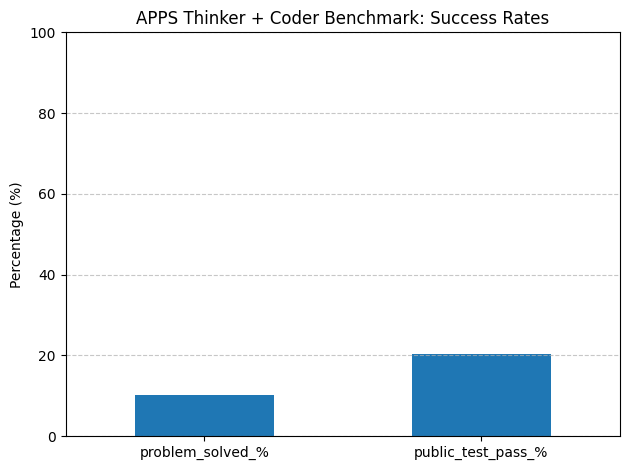


Evaluated results saved to: /content/drive/MyDrive/huggingface models/Qwen2.5-3B-Instruct__to__Qwen2.5-Coder-3B-Instruct/evaluated_results.csv


In [ ]:
# Summary statistics and plot.

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
import os

def summarize_results(df: pd.DataFrame):
    if df.empty:
        print("No results to summarize.")
        return

    df_safe = df.copy()
    # Ensure pass_rate is numeric
    df_safe["pass_rate"] = pd.to_numeric(df_safe["pass_rate"], errors='coerce').fillna(0)
    df_safe["public_test_pass_pct"] = df_safe["pass_rate"] * 100.0
    df_safe["solved"] = df_safe["solved"].astype(bool)

    summary = pd.DataFrame(
        {
            "Value": [
                df_safe["solved"].mean() * 100.0,
                df_safe["public_test_pass_pct"].mean(),
                df_safe["generation_time_s"].mean(),
            ]
        },
        index=["problem_solved_%", "public_test_pass_%", "avg_generation_time_s"],
    )

    print("=== Overall Benchmark Summary ===")
    display(summary)

    if "difficulty" in df_safe.columns:
        by_diff = (
            df_safe.groupby("difficulty")
            .agg(
                problem_solved_pct=("solved", lambda s: s.mean() * 100.0),
                public_test_pass_pct=("public_test_pass_pct", "mean"),
                avg_generation_time_s=("generation_time_s", "mean"),
                n=("problem_id", "count"),
            )
            .reset_index()
        )

        print("\n=== Summary by Difficulty ===")
        display(by_diff)

    # Plotting
    plt.figure(figsize=(10, 5))
    metrics_to_plot = ["problem_solved_%", "public_test_pass_%"]
    ax = summary.loc[metrics_to_plot].plot(kind="bar", rot=0, legend=False)
    plt.ylabel("Percentage (%)")
    plt.title("APPS Thinker + Coder Benchmark: Success Rates")
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Use the df_results generated in the previous step
summarize_results(df_results)

# Save the evaluated results to CSV for offline analysis
EVAL_SAVE_PATH = os.path.join(ARTIFACT_DIR, "evaluated_results.csv")
df_results.to_csv(EVAL_SAVE_PATH, index=False)
print(f"\nEvaluated results saved to: {EVAL_SAVE_PATH}")

# APPS Benchmark Evaluation Pipeline

This section of the notebook provides an end-to-end pipeline for evaluating the **Qwen2.5-Coder-14B-Instruct-AWQ** model on the **APPS coding benchmark**.

**Key steps include:**
1. **Setup & Model Loading:** Installs dependencies and loads the AWQ-quantized Qwen model.
2. **Dataset Preparation:** Fetches a balanced subset of the APPS dataset (Introductory, Interview, and Competition difficulties).
3. **Code Generation:** Prompts the model to generate pure Python 3 solutions for each problem and extracts the code.
4. **Evaluation:** Safely executes the generated code against public test cases using isolated subprocesses to calculate pass rates.
5. **Summary & Visualization:** Aggregates the results and visualizes the model's performance across different difficulty levels.

## 1. Setup and Model Loading
In this section, we install the necessary dependencies, configure our environment (including mounting Google Drive for caching), and load our specified model `Qwen/Qwen2.5-Coder-14B-Instruct` along with its tokenizer.

In [ ]:
# Install the packages needed for APPS + AWQ inference.

%pip install -U datasets evaluate tqdm pandas transformers accelerate autoawq


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 5.4 MB/s eta 0:00:00
  Created wheel for autoawq: filename=autoawq-0.2.9-py3-none-any.whl size=115106 sha256=9e26d3d3f6c09a4c6fe1370a48e872039b37afdaac12ee71d8e72a08f9cd6f76
  Stored in directory: /root/.cache/pip/wheels/45/1a/7b/7314b3a958454e8ce349f600829a3f0a6a05aeebf987be1e16
Successfully built autoawq
  Attempting uninstall: pyarrow
    

In [ ]:
import os
import json
import time
import re
import base64
import subprocess
import random
from io import StringIO
from typing import Any
from collections import defaultdict

import torch

os.environ["TOKENIZERS_PARALLELISM"] = "false"

MODEL_NAME = "Qwen/Qwen2.5-Coder-14B-Instruct-AWQ"

# APPS settings
DATASET_NAME = "codeparrot/apps"
DATASET_CONFIG = "all"

# Balanced Sampling Settings
SEED = 42
N_PER_DIFFICULTY = 33 # 33 * 3 difficulties (Introductory, Interview, Competition) ≈ 100
DIFFICULTY_COL = "difficulty"

# Generation settings
MAX_NEW_TOKENS = 1024
MAX_INPUT_LENGTH = 4096
DO_SAMPLE = False

# Drive/cache locations
BASE_DIR = "/content/drive/MyDrive/huggingface models"
RUN_NAME = MODEL_NAME.split("/")[-1]
ARTIFACT_DIR = os.path.join(BASE_DIR, RUN_NAME)
SAVE_PATH = os.path.join(ARTIFACT_DIR, "generated_solutions.json")

os.makedirs(ARTIFACT_DIR, exist_ok=True)
print("Artifacts will be saved to:", ARTIFACT_DIR)

Artifacts will be saved to: /content/drive/MyDrive/huggingface models/Qwen2.5-Coder-14B-Instruct-AWQ


In [ ]:
import os
import shutil
from google.colab import drive

# If the mountpoint exists and is not empty, remove it to avoid ValueError
if os.path.exists("/content/drive"):
    try:
        shutil.rmtree("/content/drive")
    except Exception as e:
        print(f"Warning: Could not remove /content/drive: {e}")

drive.mount("/content/drive", force_remount=True)

os.environ["HF_HOME"] = ARTIFACT_DIR
os.environ["TRANSFORMERS_CACHE"] = ARTIFACT_DIR

print("HF_HOME set to:", os.environ["HF_HOME"])

Mounted at /content/drive
HF_HOME set to: /content/drive/MyDrive/huggingface models/Qwen2.5-Coder-14B-Instruct-AWQ


In [ ]:
# Load tokenizer and AWQ model.

from transformers import AutoTokenizer

try:
    from awq import AutoAWQForCausalLM
except Exception as e:
    raise ImportError(
        "Could not import AutoAWQForCausalLM. Make sure autoawq installed correctly."
    ) from e

print(f"Loading tokenizer for {MODEL_NAME} ...")
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "left"

print(f"Loading AWQ model for {MODEL_NAME} ...")
model = AutoAWQForCausalLM.from_quantized(
    MODEL_NAME,
    trust_remote_code=True,
    fuse_layers=True,
    device_map="auto",
)

model.eval()

try:
    model_device = next(model.parameters()).device
except Exception:
    model_device = torch.device("cpu")

print("Model device:", model_device)
if model_device.type != "cuda":
    print("WARNING: model is not on CUDA. Check that the runtime has a GPU and enough VRAM.")


/usr/local/lib/python3.12/dist-packages/awq/__init__.py:21: DeprecationWarning: 
I have left this message as the final dev message to help you transition.

Important Notice:
- AutoAWQ is officially deprecated and will no longer be maintained.
- The last tested configuration used Torch 2.6.0 and Transformers 4.51.3.
- If future versions of Transformers break AutoAWQ compatibility, please report the issue to the Transformers project.

Alternative:
- AutoAWQ has been adopted by the vLLM Project: https://github.com/vllm-project/llm-compressor

For further inquiries, feel free to reach out:
- X: https://x.com/casper_hansen_
- LinkedIn: https://www.linkedin.com/in/casper-hansen-804005170/

  warnings.warn(_FINAL_DEV_MESSAGE, category=DeprecationWarning, stacklevel=1)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes

Loading tokenizer for Qwen/Qwen2.5-Coder-14B-Instruct-AWQ ...
Loading AWQ model for Qwen/Qwen2.5-Coder-14B-Instruct-AWQ ...


Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!
Replacing layers...: 100%|██████████| 48/48 [00:11<00:00,  4.18it/s]


Model device: cuda:0


/usr/local/lib/python3.12/dist-packages/awq/models/base.py:541: UserWarning: Skipping fusing modules because AWQ extension is not installed.No module named 'awq_ext'
  warnings.warn("Skipping fusing modules because AWQ extension is not installed." + msg)


## 2. Dataset Preparation and Inference
Here, we load the APPS benchmark dataset and extract a balanced subset across different difficulties. Then, we use the model to generate Python solutions for each problem, carefully extracting only the code from the model's output.

In [ ]:
from datasets import load_dataset

def select_balanced_subset(dataset, n_per_difficulty=25, seed=42, difficulty_col="difficulty"):
    rng = random.Random(seed)
    groups = defaultdict(list)
    for idx, item in enumerate(dataset):
        diff = item[difficulty_col]
        groups[diff].append(idx)

    difficulties = sorted(groups.keys())
    selected_indices = []
    for diff in difficulties:
        idxs = groups[diff]
        if len(idxs) < n_per_difficulty:
            print(f"Warning: Not enough problems for '{diff}'. Taking all {len(idxs)}.")
            selected_indices.extend(idxs)
        else:
            selected_indices.extend(rng.sample(idxs, n_per_difficulty))

    rng.shuffle(selected_indices)
    return dataset.select(selected_indices), difficulties

print("Loading APPS benchmark dataset...")
try:
    # Load full test set first to allow sampling
    full_dataset = load_dataset(DATASET_NAME, DATASET_CONFIG, split="test")
except Exception as e:
    print("Standard load failed, falling back to direct JSONL load.")
    data_files = {"test": "https://huggingface.co/datasets/codeparrot/apps/resolve/main/test.jsonl"}
    full_dataset = load_dataset("json", data_files=data_files, split="test")

dataset, difficulties = select_balanced_subset(
    full_dataset,
    n_per_difficulty=N_PER_DIFFICULTY,
    seed=SEED,
    difficulty_col=DIFFICULTY_COL
)

print(f"Difficulties found: {difficulties}")
print(f"Balanced subset size: {len(dataset)}")

Loading APPS benchmark dataset...
Standard load failed, falling back to direct JSONL load.
Difficulties found: ['competition', 'interview', 'introductory']
Balanced subset size: 99


In [ ]:
from collections import Counter

# Count occurrences of each difficulty in the selected subset
difficulty_counts = Counter(dataset[DIFFICULTY_COL])

print("=== Balanced Subset Summary ===")
for diff, count in sorted(difficulty_counts.items()):
    print(f"Difficulty: {diff:15} | Count: {count}")

print(f"\nTotal Problems: {len(dataset)}")

=== Balanced Subset Summary ===
Difficulty: competition     | Count: 33
Difficulty: interview       | Count: 33
Difficulty: introductory    | Count: 33

Total Problems: 99


In [ ]:
# Helpers for prompt building, text cleanup, code extraction, and generation.

def normalize_text(s: Any) -> str:
    if s is None:
        return ""
    if isinstance(s, (list, tuple)):
        return "\n".join(normalize_text(x) for x in s).strip()
    return str(s).replace("\r\n", "\n").replace("\r", "\n").strip()


def build_problem_text(item: dict) -> str:
    parts = []

    question = normalize_text(
        item.get("question")
        or item.get("prompt")
        or item.get("description")
        or item.get("problem")
        or ""
    )
    starter_code = normalize_text(
        item.get("starter_code")
        or item.get("starter code")
        or item.get("starterCode")
        or ""
    )

    if question:
        parts.append(question)

    if starter_code:
        parts.append("Starter code:\n" + starter_code)

    if not parts:
        parts.append(normalize_text(item))

    return "\n\n".join(parts).strip()


def strip_code_fences(text: Any) -> str:
    text = normalize_text(text)
    if not text:
        return ""

    blocks = re.findall(
        r"```(?:python|py)?\s*([\s\S]*?)```",
        text,
        flags=re.IGNORECASE,
    )
    if blocks:
        return "\n\n".join(block.strip() for block in blocks if block.strip()).strip()

    text = re.sub(r"^```(?:python|py)?\s*", "", text, flags=re.IGNORECASE)
    text = re.sub(r"\s*```$", "", text.strip())
    return text.strip()


def extract_code(text: Any) -> str:
    return strip_code_fences(text)


def _get_model_device():
    try:
        return next(model.parameters()).device
    except Exception:
        return torch.device("cpu")


def generate_solution(problem_text: str) -> str:
    system_prompt = """You are an expert competitive programmer.

Write a correct, efficient Python 3 solution.

Rules:
1. Output raw Python code only. No markdown, no backticks, and no explanation.
2. Use only the Python standard library.
3. Read input only from sys.stdin.read().
4. Write output only with print() or sys.stdout.write().
5. Prefer iterative solutions when possible.
6. Avoid infinite loops, brute force over large search spaces, and unnecessary recursion.
7. If recursion is needed, keep it safe and shallow.
"""

    user_prompt = f"Write a Python script to solve the following problem:\n\n{problem_text}"

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]

    try:
        prompt = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )
    except Exception:
        prompt = system_prompt + "\n\n" + user_prompt

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_INPUT_LENGTH,
    )

    model_device = _get_model_device()
    inputs = {k: v.to(model_device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=DO_SAMPLE,
            temperature=0.2,
            top_p=0.9,
            use_cache=True,
            pad_token_id=tokenizer.eos_token_id,
        )

    prompt_len = inputs["input_ids"].shape[-1]
    generated_ids = outputs[0][prompt_len:]
    return tokenizer.decode(generated_ids, skip_special_tokens=True).strip()


In [ ]:
# Generate solutions for the benchmark.

from tqdm.auto import tqdm

results = []

print("Generating solutions ...")
for idx, item in enumerate(tqdm(dataset)):
    problem_id = item.get("problem_id", item.get("id", item.get("uid", idx)))
    difficulty = item.get("difficulty", "unknown")
    problem_text = build_problem_text(item)

    if not problem_text:
        continue

    start = time.perf_counter()
    generation_error = ""
    raw_output = ""
    clean_code = ""

    try:
        raw_output = generate_solution(problem_text)
        clean_code = extract_code(raw_output)
    except Exception as e:
        generation_error = repr(e)

    generation_time_s = time.perf_counter() - start

    results.append(
        {
            "index": idx,
            "problem_id": problem_id,
            "difficulty": difficulty,
            "generated_code": clean_code,
            "generation_error": generation_error,
            "generation_time_s": round(generation_time_s, 3),
            "prompt_chars": len(problem_text),
            "test_cases": item.get("input_output", ""),
        }
    )

    if (idx + 1) % 10 == 0:
        with open(SAVE_PATH, "w", encoding="utf-8") as f:
            json.dump(results, f, indent=2)
        print(f"Saved progress after {idx + 1} problems.")

print(f"Generated {len(results)} solutions.")


Generating solutions ...


  0%|          | 0/99 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to repres

Saved progress after 10 problems.
Saved progress after 20 problems.
Saved progress after 30 problems.
Saved progress after 40 problems.
Saved progress after 50 problems.
Saved progress after 60 problems.
Saved progress after 70 problems.
Saved progress after 80 problems.
Saved progress after 90 problems.
Generated 99 solutions.


In [ ]:
# Save generated solutions.

with open(SAVE_PATH, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)

print(f"Saved {len(results)} generated solutions to: {SAVE_PATH}")


Saved 99 generated solutions to: /content/drive/MyDrive/huggingface models/Qwen2.5-Coder-14B-Instruct-AWQ/generated_solutions.json


## 3. Running Test Cases and Evaluation
Finally, this section evaluates the generated solutions. It runs each solution against public test cases using an isolated subprocess (to prevent infinite loops) and summarizes the overall metrics such as pass rate and total problems solved.


In [ ]:
# Public-test evaluation helpers.

import sys
import math
import json
import base64
import subprocess
from IPython.display import display
import pandas as pd

def parse_test_cases(raw):
    if not raw:
        return [], []

    if isinstance(raw, dict):
        data = raw
    else:
        try:
            data = json.loads(raw)
        except Exception:
            return [], []

    inputs = data.get("inputs") or data.get("input") or []
    outputs = data.get("outputs") or data.get("output") or []

    if len(inputs) != len(outputs):
        n = min(len(inputs), len(outputs))
        inputs = inputs[:n]
        outputs = outputs[:n]

    return inputs, outputs

def forgiving_compare(actual, expected, tolerance=1e-4):
    actual = normalize_text(actual)
    expected = normalize_text(expected)

    if actual == expected:
        return True

    actual_tokens = actual.split()
    expected_tokens = expected.split()

    if len(actual_tokens) != len(expected_tokens):
        return False

    for a, e in zip(actual_tokens, expected_tokens):
        try:
            if abs(float(a) - float(e)) > tolerance:
                return False
        except ValueError:
            if a != e and a.lower() != e.lower():
                return False

    return True

def run_code_subprocess(code, inp, timeout_sec=5):
    # Ensure input is a string for the subprocess
    if not isinstance(inp, str):
        inp = str(inp)

    encoded = base64.b64encode(code.encode("utf-8")).decode("ascii")

    wrapper = f"""
import base64
import traceback

code = base64.b64decode({encoded!r}).decode("utf-8")
namespace = {{\"__name__\": \"__main__\"}}

try:
    exec(compile(code, \"<solution>\", \"exec\"), namespace, namespace)
except Exception:
    traceback.print_exc()
"""

    proc = subprocess.run(
        [sys.executable, "-c", wrapper],
        input=inp,
        text=True,
        capture_output=True,
        timeout=timeout_sec,
    )

    return proc.stdout, proc.stderr, proc.returncode

def evaluate_single_case(code, inp, expected_out, timeout_sec=5):
    try:
        stdout, stderr, returncode = run_code_subprocess(code, inp, timeout_sec=timeout_sec)
    except subprocess.TimeoutExpired:
        return False

    return forgiving_compare(stdout, expected_out)

def run_public_tests(problem_id, code, test_cases_json, timeout_sec=5):
    inputs, outputs = parse_test_cases(test_cases_json)

    total = len(inputs)
    if total == 0:
        return {
            "passed": 0,
            "total": 0,
            "pass_rate": 0.0,
            "solved": False,
            "status": "No public tests available",
        }

    try:
        compile(code, "<solution>", "exec")
    except SyntaxError as e:
        return {
            "passed": 0,
            "total": total,
            "pass_rate": 0.0,
            "solved": False,
            "status": f"Syntax Error: {e.msg}",
        }

    passed = 0
    for inp, exp in zip(inputs, outputs):
        # Ensure we pass strings to the evaluator
        if evaluate_single_case(code, str(inp), str(exp), timeout_sec=timeout_sec):
            passed += 1

    return {
        "passed": passed,
        "total": total,
        "pass_rate": passed / total if total else 0.0,
        "solved": passed == total,
        "status": f"{passed}/{total} Passed",
    }

In [ ]:
import json
import os

if os.path.exists(SAVE_PATH):
    with open(SAVE_PATH, 'r', encoding='utf-8') as f:
        results = json.load(f)
    print(f"Successfully loaded {len(results)} results from {SAVE_PATH}")
else:
    print(f"File not found at {SAVE_PATH}. Please ensure the generation step completed successfully.")

Successfully loaded 99 results from /content/drive/MyDrive/huggingface models/Qwen2.5-Coder-14B-Instruct-AWQ/generated_solutions.json


In [ ]:
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor

# Run public-test evaluation.
print("=== STARTING EVALUATION (Multi-threaded) ===")

def normalize_text(s):
    if s is None: return ""
    if isinstance(s, (list, tuple)): return "\n".join(normalize_text(x) for x in s).strip()
    return str(s).replace("\r\n", "\n").replace("\r", "\n").strip()

def process_problem(res):
    metrics = run_public_tests(
        res["problem_id"],
        res["generated_code"],
        res["test_cases"],
        timeout_sec=5,
    )
    res.update(metrics)
    return res

# Using 8 workers to speed up the process.
# Subprocess calls are largely I/O bound waits, so threading is effective here.
MAX_WORKERS = 8

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    # Wrap with list() to ensure all tasks are submitted before tqdm starts iterating over the results
    list(tqdm(executor.map(process_problem, results), total=len(results), desc="Evaluating problems"))

df_results = pd.DataFrame(results)

print("\n=== FINAL APPS BENCHMARK SUMMARY ===")
display(df_results[[
    "problem_id",
    "difficulty",
    "status",
    "generation_time_s",
    "pass_rate",
    "solved",
]])

=== STARTING EVALUATION (Multi-threaded) ===


Evaluating problems:   0%|          | 0/99 [00:00<?, ?it/s]


=== FINAL APPS BENCHMARK SUMMARY ===


,problem_id,difficulty,status,generation_time_s,pass_rate,solved
0,3114,competition,0/3 Passed,41.022,0.000000,False
1,653,interview,38/38 Passed,21.443,1.000000,True
2,3604,competition,1/2 Passed,32.783,0.500000,False
3,379,interview,45/54 Passed,52.640,0.833333,False
4,3558,competition,0/2 Passed,24.580,0.000000,False
...,...,...,...,...,...,...
94,1139,interview,5/23 Passed,28.240,0.217391,False
95,1470,interview,1/17 Passed,14.049,0.058824,False
96,2261,interview,0/5 Passed,14.979,0.000000,False
97,3223,competition,2/3 Passed,28.423,0.666667,False


Overall summary


,Single Model
problem_solved_%,29.292929
public_test_pass_%,46.615546
avg_generation_time_s,34.189818


By difficulty


,difficulty,problem_solved_pct,public_test_pass_pct,avg_generation_time_s,n
0,competition,9.090909,28.339573,48.240879,33
1,interview,15.151515,37.472397,32.825121,33
2,introductory,63.636364,74.034669,21.503455,33


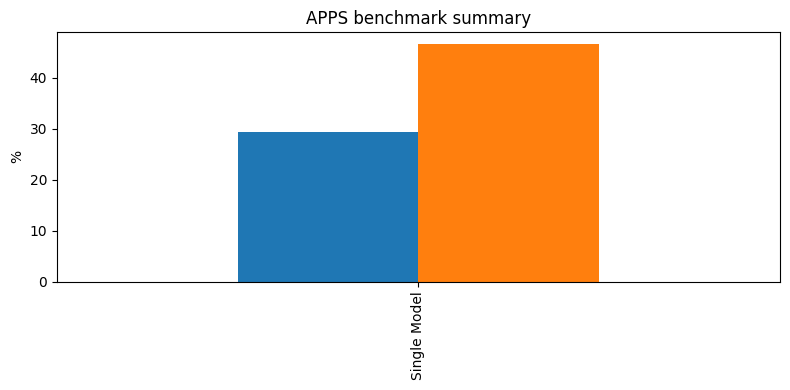

Saved evaluated results to: /content/drive/MyDrive/huggingface models/Qwen2.5-Coder-14B-Instruct-AWQ/evaluated_results.csv


In [ ]:
# Summary statistics and plot.

import matplotlib.pyplot as plt
from IPython.display import display

def summarize_results(df: pd.DataFrame):
    if df.empty:
        print("No results.")
        return

    df_safe = df.copy()
    df_safe["public_test_pass_pct"] = df_safe["pass_rate"] * 100.0

    summary = pd.DataFrame(
        {
            "Single Model": [
                df_safe["solved"].mean() * 100.0,
                df_safe["public_test_pass_pct"].mean(),
                df_safe["generation_time_s"].mean(),
            ]
        },
        index=["problem_solved_%", "public_test_pass_%", "avg_generation_time_s"],
    )

    print("Overall summary")
    display(summary)

    if "difficulty" in df_safe.columns:
        by_diff = (
            df_safe.groupby("difficulty")
            .agg(
                problem_solved_pct=("solved", lambda s: s.mean() * 100.0),
                public_test_pass_pct=("public_test_pass_pct", "mean"),
                avg_generation_time_s=("generation_time_s", "mean"),
                n=("problem_id", "count"),
            )
            .reset_index()
        )

        print("By difficulty")
        display(by_diff)

    ax = summary.loc[["problem_solved_%", "public_test_pass_%"]].T.plot(
        kind="bar",
        figsize=(8, 4),
        legend=False,
    )
    ax.set_ylabel("%")
    ax.set_xlabel("")
    ax.set_title("APPS benchmark summary")
    plt.tight_layout()
    plt.show()

summarize_results(df_results)

EVAL_SAVE_PATH = os.path.join(ARTIFACT_DIR, "evaluated_results.csv")
df_results.to_csv(EVAL_SAVE_PATH, index=False)
print(f"Saved evaluated results to: {EVAL_SAVE_PATH}")


# Two-Stage Reasoning and Coding Evaluation on APPS

This section of the notebook implements a two-stage approach to solve competitive programming problems from the APPS benchmark:

1. **Thinker Stage:** Uses `deepseek-ai/DeepSeek-R1-Distill-Qwen-7B` to analyze the problem and generate a logical reasoning plan without writing code.
2. **Coder Stage:** Feeds the reasoning plan to `Qwen/Qwen2.5-Coder-3B-Instruct` to implement the final Python 3 solution.
3. **Evaluation:** Securely tests the generated code against public test cases using isolated subprocesses to prevent infinite loops, and visualizes the performance metrics (pass rate, percentage solved) across different difficulty levels.

## 1. Setup and Model Loading
In this section, we install the necessary dependencies, configure our environment (including mounting Google Drive for caching), and load our specified models `deepseek-ai/DeepSeek-R1-Distill-Qwen-7B` & `Qwen/Qwen2.5-Coder-3B-Instruct` along with its tokenizer.

In [ ]:
# Install the packages needed for APPS + Transformers inference.
%pip install -U datasets evaluate tqdm pandas transformers accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 12.8 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existin

In [ ]:
# Configuration

import os
import json
import time
import re
import base64
import subprocess
import random
from collections import defaultdict
from typing import Any

import torch

os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Swap these two model names as needed.
THINKER_MODEL_NAME = "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B"
CODER_MODEL_NAME = "Qwen/Qwen2.5-Coder-3B-Instruct"

# APPS settings
DATASET_NAME = "codeparrot/apps"
DATASET_CONFIG = "all"
DATASET_SPLIT = "test"   # Load full test set first to sample from it

# Balanced Sampling Settings
SEED = 42
N_PER_DIFFICULTY = 33 # 33 * 3 difficulties (Introductory, Interview, Competition) ≈ 100
DIFFICULTY_COL = "difficulty"

# Generation settings
THINKER_MAX_NEW_TOKENS = 1024 #increasing this did not help with the results too much
CODER_MAX_NEW_TOKENS = 1024
MAX_INPUT_LENGTH = 4096
DO_SAMPLE = False

# Drive/cache locations
BASE_DIR = "/content/drive/MyDrive/huggingface models"
RUN_NAME = f"{THINKER_MODEL_NAME.split('/')[-1]}__to__{CODER_MODEL_NAME.split('/')[-1]}"
ARTIFACT_DIR = os.path.join(BASE_DIR, RUN_NAME)
SAVE_PATH = os.path.join(ARTIFACT_DIR, "generated_solutions.json")

os.makedirs(ARTIFACT_DIR, exist_ok=True)
print("Artifacts will be saved to:", ARTIFACT_DIR)


Artifacts will be saved to: /content/drive/MyDrive/huggingface models/DeepSeek-R1-Distill-Qwen-7B__to__Qwen2.5-Coder-3B-Instruct


In [ ]:
# Mount Google Drive and set HF cache locations.
import os
import shutil
from google.colab import drive

# Fix: Ensure the mount point is clean if it exists but isn't mounted properly
mount_path = "/content/drive"
if os.path.exists(mount_path) and os.listdir(mount_path):
    print(f"Cleaning up {mount_path} to prepare for mounting...")
    try:
        # We only attempt to remove it if it's not actually a mount point yet
        if not os.path.ismount(mount_path):
            shutil.rmtree(mount_path, ignore_errors=True)
    except Exception as e:
        print(f"Note: Could not fully clear directory: {e}")

drive.mount(mount_path, force_remount=True)

os.environ["HF_HOME"] = ARTIFACT_DIR
os.environ["TRANSFORMERS_CACHE"] = ARTIFACT_DIR

print("HF_HOME set to:", os.environ["HF_HOME"])

Cleaning up /content/drive to prepare for mounting...
Mounted at /content/drive
HF_HOME set to: /content/drive/MyDrive/huggingface models/DeepSeek-R1-Distill-Qwen-7B__to__Qwen2.5-Coder-3B-Instruct


In [ ]:
# Load thinker and coder tokenizers/models.

from transformers import AutoTokenizer, AutoModelForCausalLM

def load_model_and_tokenizer(model_name: str, cache_subdir: str):
    os.makedirs(cache_subdir, exist_ok=True)

    print(f"Loading tokenizer for {model_name} ...")
    tokenizer = AutoTokenizer.from_pretrained(
        model_name,
        trust_remote_code=True,
        cache_dir=cache_subdir,
    )

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"

    dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32

    print(f"Loading model for {model_name} ...")
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=dtype,
        device_map="auto",
        low_cpu_mem_usage=True,
        trust_remote_code=True,
        cache_dir=cache_subdir,
    )

    model.eval()

    try:
        device = next(model.parameters()).device
    except Exception:
        device = torch.device("cpu")

    print(f"{model_name} device:", device)
    return tokenizer, model, device


THINKER_CACHE_DIR = os.path.join(ARTIFACT_DIR, THINKER_MODEL_NAME.split("/")[-1])
CODER_CACHE_DIR = os.path.join(ARTIFACT_DIR, CODER_MODEL_NAME.split("/")[-1])

thinker_tokenizer, thinker_model, thinker_device = load_model_and_tokenizer(
    THINKER_MODEL_NAME,
    THINKER_CACHE_DIR,
)

coder_tokenizer, coder_model, coder_device = load_model_and_tokenizer(
    CODER_MODEL_NAME,
    CODER_CACHE_DIR,
)

if thinker_device.type != "cuda" or coder_device.type != "cuda":
    print("WARNING: one of the models is not fully on CUDA. Check runtime VRAM.")

Loading tokenizer for deepseek-ai/DeepSeek-R1-Distill-Qwen-7B ...


config.json:   0%|          | 0.00/680 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loading model for deepseek-ai/DeepSeek-R1-Distill-Qwen-7B ...


...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Qwen/Qwen2.5-Coder-3B-Instruct device: cuda:0


## 2. Dataset Preparation and Inference
Here, we load the APPS benchmark dataset and extract a balanced subset across different difficulties. Then, we use the model to generate Python solutions for each problem, carefully extracting only the code from the model's output.

In [ ]:
# Load APPS and select balanced subset.

from datasets import load_dataset

def select_balanced_subset(dataset, n_per_difficulty=25, seed=42, difficulty_col="difficulty"):
    rng = random.Random(seed)
    groups = defaultdict(list)
    for idx, item in enumerate(dataset):
        diff = item[difficulty_col]
        groups[diff].append(idx)

    difficulties = sorted(groups.keys())
    selected_indices = []
    for diff in difficulties:
        idxs = groups[diff]
        if len(idxs) < n_per_difficulty:
            print(f"Warning: Not enough problems for '{diff}'. Taking all {len(idxs)}.")
            selected_indices.extend(idxs)
        else:
            selected_indices.extend(rng.sample(idxs, n_per_difficulty))

    rng.shuffle(selected_indices)
    return dataset.select(selected_indices), difficulties

print("Loading APPS benchmark dataset...")
try:
    # Load full test set first to allow sampling
    full_dataset = load_dataset(DATASET_NAME, DATASET_CONFIG, split="test")
except Exception as e:
    print("Standard load failed, falling back to direct JSONL load.")
    data_files = {"test": "https://huggingface.co/datasets/codeparrot/apps/resolve/main/test.jsonl"}
    full_dataset = load_dataset("json", data_files=data_files, split="test")

dataset, difficulties = select_balanced_subset(
    full_dataset,
    n_per_difficulty=N_PER_DIFFICULTY,
    seed=SEED,
    difficulty_col=DIFFICULTY_COL
)

print(f"Difficulties found: {difficulties}")
print(f"Balanced subset size: {len(dataset)}")
print("Columns:", dataset.column_names)

Loading APPS benchmark dataset...


README.md: 0.00B [00:00, ?B/s]

apps.py: 0.00B [00:00, ?B/s]

Standard load failed, falling back to direct JSONL load.


test.jsonl:   0%|          | 0.00/1.29G [00:00<?, ?B/s]

Generating test split: 0 examples [00:00, ? examples/s]

Difficulties found: ['competition', 'interview', 'introductory']
Balanced subset size: 99
Columns: ['id', 'question', 'solutions', 'input_output', 'difficulty', 'url', 'starter_code']


In [ ]:
from collections import Counter

# Count occurrences of each difficulty in the selected subset
difficulty_counts = Counter(dataset[DIFFICULTY_COL])

print(f"Total problems in subset: {len(dataset)}")
print("Breakdown by difficulty:")
for diff, count in sorted(difficulty_counts.items()):
    print(f" - {diff}: {count} problems")

Total problems in subset: 99
Breakdown by difficulty:
 - competition: 33 problems
 - interview: 33 problems
 - introductory: 33 problems


In [ ]:
# Helpers for prompt building, text cleanup, code extraction, and generation.

def normalize_text(s: Any) -> str:
    if s is None:
        return ""
    if isinstance(s, (list, tuple)):
        return "\n".join(normalize_text(x) for x in s).strip()
    return str(s).replace("\r\n", "\n").replace("\r", "\n").strip()


def build_problem_text(item: dict) -> str:
    parts = []

    question = normalize_text(
        item.get("question")
        or item.get("prompt")
        or item.get("description")
        or item.get("problem")
        or ""
    )
    starter_code = normalize_text(
        item.get("starter_code")
        or item.get("starter code")
        or item.get("starterCode")
        or ""
    )

    if question:
        parts.append(question)

    if starter_code:
        parts.append("Starter code:\n" + starter_code)

    if not parts:
        parts.append(normalize_text(item))

    return "\n\n".join(parts).strip()


def strip_code_fences(text: Any) -> str:
    text = normalize_text(text)
    if not text:
        return ""

    blocks = re.findall(
        r"```(?:python|py)?\s*([\s\S]*?)```",
        text,
        flags=re.IGNORECASE,
    )
    if blocks:
        return "\n\n".join(block.strip() for block in blocks if block.strip()).strip()

    text = re.sub(r"^```(?:python|py)?\s*", "", text, flags=re.IGNORECASE)
    text = re.sub(r"\s*```$", "", text.strip())
    return text.strip()


def extract_code(text: Any) -> str:
    return strip_code_fences(text)


def _get_model_device(model):
    try:
        return next(model.parameters()).device
    except Exception:
        return torch.device("cpu")


def _encode_for_model(tokenizer, prompt: str, max_length: int):
    return tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=max_length,
    )


def generate_thinker_plan(problem_text: str) -> str:
    system_prompt = """You are an expert competitive programming analyst.
Your task is to produce a compact but useful solution plan.

Rules:
1. Do NOT write code.
2. Output only the reasoning plan.
3. Include the key idea, algorithm, data structures, complexity, and edge cases.
4. Keep it concise and implementation-oriented.
5. Avoid vague advice. Be concrete.
"""

    user_prompt = f"""Problem:
{problem_text}

Return a concise logical solution plan that a coder model can implement."""

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]

    try:
        prompt = thinker_tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )
    except Exception:
        prompt = system_prompt + "\n\n" + user_prompt

    inputs = _encode_for_model(thinker_tokenizer, prompt, MAX_INPUT_LENGTH)
    model_device = _get_model_device(thinker_model)
    inputs = {k: v.to(model_device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = thinker_model.generate(
            **inputs,
            max_new_tokens=THINKER_MAX_NEW_TOKENS,
            do_sample=DO_SAMPLE,
            temperature=0.5,
            top_p=0.9,
            use_cache=True,
            pad_token_id=thinker_tokenizer.eos_token_id,
        )

    prompt_len = inputs["input_ids"].shape[-1]
    generated_ids = outputs[0][prompt_len:]
    text = thinker_tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

    # DeepSeek-R1 typically outputs <think>...</think> block for reasoning.
    # We strip it out to provide only the final plan to the coder.
    text = re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL).strip()
    return text


def generate_coder_solution(problem_text: str, thinker_plan: str) -> str:
    system_prompt = """You are an expert competitive programmer.

Write a correct, efficient Python 3 solution.

Rules:
1. Output raw Python code only. No markdown, no backticks, and no explanation.
2. Use only the Python standard library.
3. Read input only from sys.stdin.read().
4. Write output only with print() or sys.stdout.write().
5. Prefer iterative solutions when possible.
6. Avoid infinite loops, brute force over large search spaces, and unnecessary recursion.
7. If recursion is needed, keep it safe and shallow.
"""

    user_prompt = f"""Problem:
{problem_text}

Solution plan from a reasoning model:
{thinker_plan}

Now write the full Python 3 solution."""

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]

    try:
        prompt = coder_tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )
    except Exception:
        prompt = system_prompt + "\n\n" + user_prompt

    inputs = _encode_for_model(coder_tokenizer, prompt, MAX_INPUT_LENGTH)
    model_device = _get_model_device(coder_model)
    inputs = {k: v.to(model_device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = coder_model.generate(
            **inputs,
            max_new_tokens=CODER_MAX_NEW_TOKENS,
            do_sample=DO_SAMPLE,
            temperature=0.2,
            top_p=0.9,
            use_cache=True,
            pad_token_id=coder_tokenizer.eos_token_id,
        )

    prompt_len = inputs["input_ids"].shape[-1]
    generated_ids = outputs[0][prompt_len:]
    return coder_tokenizer.decode(generated_ids, skip_special_tokens=True).strip()


def generate_solution(problem_text: str):
    thinker_plan = generate_thinker_plan(problem_text)
    raw_output = generate_coder_solution(problem_text, thinker_plan)
    return thinker_plan, raw_output


In [ ]:
# Generate solutions for the benchmark.

from tqdm.auto import tqdm

results = []

print("Generating solutions ...")
for idx, item in enumerate(tqdm(dataset)):
    problem_id = item.get("problem_id", item.get("id", item.get("uid", idx)))
    difficulty = item.get("difficulty", "unknown")
    problem_text = build_problem_text(item)

    if not problem_text:
        continue

    start = time.perf_counter()
    generation_error = ""
    thinker_plan = ""
    raw_output = ""
    clean_code = ""

    try:
        thinker_plan, raw_output = generate_solution(problem_text)
        clean_code = extract_code(raw_output)
    except Exception as e:
        generation_error = repr(e)

    generation_time_s = time.perf_counter() - start

    results.append(
        {
            "index": idx,
            "problem_id": problem_id,
            "difficulty": difficulty,
            "thinker_plan": thinker_plan,
            "generated_code": clean_code,
            "generation_error": generation_error,
            "generation_time_s": round(generation_time_s, 3),
            "thinker_plan_chars": len(thinker_plan),
            "prompt_chars": len(problem_text),
            "test_cases": item.get("input_output", ""),
        }
    )

    if (idx + 1) % 10 == 0:
        with open(SAVE_PATH, "w", encoding="utf-8") as f:
            json.dump(results, f, indent=2)
        print(f"Saved progress after {idx + 1} problems.")

print(f"Generated {len(results)} solutions.")

Generating solutions ...


  0%|          | 0/99 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Saved progress after 10 problems.
Saved progress after 20 problems.
Saved progress after 30 problems.
Saved progress after 40 problems.
Saved progress after 50 problems.
Saved progress after 60 problems.
Saved progress after 70 problems.
Saved progress after 80 problems.
Saved progress after 90 problems.
Generated 99 solutions.


In [ ]:
# Save generated solutions.

with open(SAVE_PATH, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)

print(f"Saved {len(results)} generated solutions to: {SAVE_PATH}")

Saved 99 generated solutions to: /content/drive/MyDrive/huggingface models/DeepSeek-R1-Distill-Qwen-7B__to__Qwen2.5-Coder-3B-Instruct/generated_solutions.json


## 3. Running Test Cases and Evaluation
Finally, this section evaluates the generated solutions. It runs each solution against public test cases using an isolated subprocess (to prevent infinite loops) and summarizes the overall metrics such as pass rate and total problems solved.

In [ ]:
# Public-test evaluation helpers.

import sys
import math
import json
import base64
import subprocess
from IPython.display import display
import pandas as pd
from typing import Any

def normalize_text(s: Any) -> str:
    if s is None:
        return ""
    if isinstance(s, (list, tuple)):
        return "\n".join(normalize_text(x) for x in s).strip()
    return str(s).replace("\r\n", "\n").replace("\r", "\n").strip()

def parse_test_cases(raw):
    if not raw:
        return [], []

    if isinstance(raw, dict):
        data = raw
    else:
        try:
            data = json.loads(raw)
        except Exception:
            return [], []

    inputs = data.get("inputs") or data.get("input") or []
    outputs = data.get("outputs") or data.get("output") or []

    if len(inputs) != len(outputs):
        n = min(len(inputs), len(outputs))
        inputs = inputs[:n]
        outputs = outputs[:n]

    return inputs, outputs

def forgiving_compare(actual, expected, tolerance=1e-4):
    actual = normalize_text(actual)
    expected = normalize_text(expected)

    if actual == expected:
        return True

    actual_tokens = actual.split()
    expected_tokens = expected.split()

    if len(actual_tokens) != len(expected_tokens):
        return False

    for a, e in zip(actual_tokens, expected_tokens):
        try:
            if abs(float(a) - float(e)) > tolerance:
                return False
        except ValueError:
            if a != e and a.lower() != e.lower():
                return False

    return True

def run_code_subprocess(code, inp, timeout_sec=5):
    # Ensure input is a string
    inp_str = normalize_text(inp)
    encoded = base64.b64encode(code.encode("utf-8")).decode("ascii")

    wrapper = f"""
import base64
import traceback

code = base64.b64decode({encoded!r}).decode("utf-8")
namespace = {{"__name__": "__main__"}}

try:
    exec(compile(code, "<solution>", "exec"), namespace, namespace)
except Exception:
    traceback.print_exc()
"""

    proc = subprocess.run(
        [sys.executable, "-c", wrapper],
        input=inp_str,
        text=True,
        capture_output=True,
        timeout=timeout_sec,
    )

    return proc.stdout, proc.stderr, proc.returncode

def evaluate_single_case(code, inp, expected_out, timeout_sec=5):
    try:
        stdout, stderr, returncode = run_code_subprocess(code, inp, timeout_sec=timeout_sec)
    except subprocess.TimeoutExpired:
        return False

    return forgiving_compare(stdout, expected_out)

def run_public_tests(problem_id, code, test_cases_json, timeout_sec=5):
    inputs, outputs = parse_test_cases(test_cases_json)

    total = len(inputs)
    if total == 0:
        return {
            "passed": 0,
            "total": 0,
            "pass_rate": 0.0,
            "solved": False,
            "status": "No public tests available",
        }

    try:
        compile(code, "<solution>", "exec")
    except SyntaxError as e:
        return {
            "passed": 0,
            "total": total,
            "pass_rate": 0.0,
            "solved": False,
            "status": f"Syntax Error: {e.msg}",
        }

    passed = 0
    for inp, exp in zip(inputs, outputs):
        if evaluate_single_case(code, inp, exp, timeout_sec=timeout_sec):
            passed += 1

    return {
        "passed": passed,
        "total": total,
        "pass_rate": passed / total if total else 0.0,
        "solved": passed == total,
        "status": f"{passed}/{total} Passed",
    }

In [ ]:
from google.colab import drive
import os
import shutil

# Robust Drive Mount
mount_path = '/content/drive'
if not os.path.ismount(mount_path):
    try:
        drive.mount(mount_path, force_remount=True)
    except ValueError:
        print("Mount point busy, attempting to clear and retry...")
        if os.path.exists(mount_path):
            shutil.rmtree(mount_path, ignore_errors=True)
        drive.mount(mount_path, force_remount=True)
else:
    print("Drive already mounted.")

# Re-define the critical paths from the configuration cell
THINKER_MODEL_NAME = "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B"
CODER_MODEL_NAME = "Qwen/Qwen2.5-Coder-3B-Instruct"
BASE_DIR = "/content/drive/MyDrive/huggingface models"
RUN_NAME = f"{THINKER_MODEL_NAME.split('/')[-1]}__to__{CODER_MODEL_NAME.split('/')[-1]}"
ARTIFACT_DIR = os.path.join(BASE_DIR, RUN_NAME)
# Note: Checking for the specific version used in your previous successful run
SAVE_PATH = os.path.join(ARTIFACT_DIR, "generated_solutions2.json")

print(f"Verified ARTIFACT_DIR: {ARTIFACT_DIR}")
print(f"Verified SAVE_PATH: {SAVE_PATH}")

if os.path.exists(SAVE_PATH):
    print("Found existing results file.")
else:
    # Fallback to the other common name if 'solutions2' isn't found
    ALT_PATH = os.path.join(ARTIFACT_DIR, "generated_solutions.json")
    if os.path.exists(ALT_PATH):
        SAVE_PATH = ALT_PATH
        print(f"Found results at alternative path: {SAVE_PATH}")
    else:
        print("Warning: results file not found. Please ensure the generation step completed.")


Drive already mounted.
Verified ARTIFACT_DIR: /content/drive/MyDrive/huggingface models/DeepSeek-R1-Distill-Qwen-7B__to__Qwen2.5-Coder-3B-Instruct
Verified SAVE_PATH: /content/drive/MyDrive/huggingface models/DeepSeek-R1-Distill-Qwen-7B__to__Qwen2.5-Coder-3B-Instruct/generated_solutions2.json
Found results at alternative path: /content/drive/MyDrive/huggingface models/DeepSeek-R1-Distill-Qwen-7B__to__Qwen2.5-Coder-3B-Instruct/generated_solutions.json


In [ ]:
# Run public-test evaluation.
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor
import json
import pandas as pd
import base64
import subprocess

print("=== STARTING EVALUATION ===")

# Load results from the save path if they aren't in memory
if 'results' not in globals() or not results:
    print(f"Loading results from {SAVE_PATH}...")
    with open(SAVE_PATH, "r", encoding="utf-8") as f:
        results = json.load(f)

def process_result(res):
    if res.get("generation_error"):
        res.update({
            "passed": 0,
            "total": 0,
            "pass_rate": 0.0,
            "solved": False,
            "status": f"Generation error: {res['generation_error']}",
        })
        return res

    metrics = run_public_tests(
        res["problem_id"],
        res["generated_code"],
        res["test_cases"],
        timeout_sec=5,
    )
    res.update(metrics)
    return res

# Use ThreadPoolExecutor for faster evaluation
print(f"Evaluating {len(results)} results using multi-threading...")
with ThreadPoolExecutor(max_workers=8) as executor:
    results = list(tqdm(executor.map(process_result, results), total=len(results)))

df_results = pd.DataFrame(results)

print("\n=== FINAL APPS BENCHMARK SUMMARY ===")
from IPython.display import display
display(df_results[[
    "problem_id",
    "difficulty",
    "status",
    "generation_time_s",
    "pass_rate",
    "solved",
]])

=== STARTING EVALUATION ===
Loading results from /content/drive/MyDrive/huggingface models/DeepSeek-R1-Distill-Qwen-7B__to__Qwen2.5-Coder-3B-Instruct/generated_solutions.json...
Evaluating 99 results using multi-threading...


  0%|          | 0/99 [00:00<?, ?it/s]


=== FINAL APPS BENCHMARK SUMMARY ===


,problem_id,difficulty,status,generation_time_s,pass_rate,solved
0,3114,competition,0/3 Passed,95.709,0.000000,False
1,653,interview,1/38 Passed,76.937,0.026316,False
2,3604,competition,0/2 Passed,83.549,0.000000,False
3,379,interview,32/54 Passed,85.691,0.592593,False
4,3558,competition,0/2 Passed,79.431,0.000000,False
...,...,...,...,...,...,...
94,1139,interview,0/23 Passed,81.024,0.000000,False
95,1470,interview,2/17 Passed,72.876,0.117647,False
96,2261,interview,1/5 Passed,71.372,0.200000,False
97,3223,competition,0/3 Passed,107.416,0.000000,False


=== Overall Benchmark Summary ===


,Value
problem_solved_%,24.242424
public_test_pass_%,33.689688
avg_generation_time_s,77.711465



=== Summary by Difficulty ===


,difficulty,problem_solved_pct,public_test_pass_pct,avg_generation_time_s,n
0,competition,6.060606,16.109658,82.576394,33
1,interview,24.242424,32.601203,80.005636,33
2,introductory,42.424242,52.358202,70.552364,33


<Figure size 1000x500 with 0 Axes>

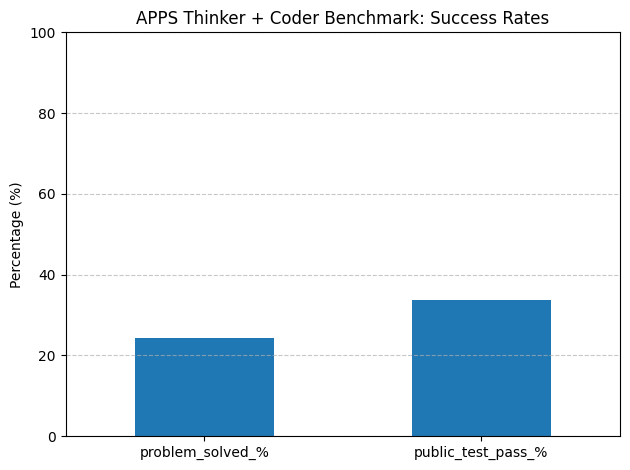


Evaluated results saved to: /content/drive/MyDrive/huggingface models/DeepSeek-R1-Distill-Qwen-7B__to__Qwen2.5-Coder-3B-Instruct/evaluated_results.csv


In [ ]:
# Summary statistics and plot.

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
import os

def summarize_results(df: pd.DataFrame):
    if df.empty:
        print("No results to summarize.")
        return

    df_safe = df.copy()
    # Ensure pass_rate is numeric
    df_safe["pass_rate"] = pd.to_numeric(df_safe["pass_rate"], errors='coerce').fillna(0)
    df_safe["public_test_pass_pct"] = df_safe["pass_rate"] * 100.0
    df_safe["solved"] = df_safe["solved"].astype(bool)

    summary = pd.DataFrame(
        {
            "Value": [
                df_safe["solved"].mean() * 100.0,
                df_safe["public_test_pass_pct"].mean(),
                df_safe["generation_time_s"].mean(),
            ]
        },
        index=["problem_solved_%", "public_test_pass_%", "avg_generation_time_s"],
    )

    print("=== Overall Benchmark Summary ===")
    display(summary)

    if "difficulty" in df_safe.columns:
        by_diff = (
            df_safe.groupby("difficulty")
            .agg(
                problem_solved_pct=("solved", lambda s: s.mean() * 100.0),
                public_test_pass_pct=("public_test_pass_pct", "mean"),
                avg_generation_time_s=("generation_time_s", "mean"),
                n=("problem_id", "count"),
            )
            .reset_index()
        )

        print("\n=== Summary by Difficulty ===")
        display(by_diff)

    # Plotting
    plt.figure(figsize=(10, 5))
    metrics_to_plot = ["problem_solved_%", "public_test_pass_%"]
    ax = summary.loc[metrics_to_plot].plot(kind="bar", rot=0, legend=False)
    plt.ylabel("Percentage (%)")
    plt.title("APPS Thinker + Coder Benchmark: Success Rates")
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Use the df_results generated in the previous step
summarize_results(df_results)

# Save the evaluated results to CSV for offline analysis
EVAL_SAVE_PATH = os.path.join(ARTIFACT_DIR, "evaluated_results.csv")
df_results.to_csv(EVAL_SAVE_PATH, index=False)
print(f"\nEvaluated results saved to: {EVAL_SAVE_PATH}")

APPS Benchmark Evaluation Pipeline

This section of the notebook evaluates the coding capabilities of a Large Language Model (specifically `Qwen/Qwen2.5-Coder-3B-Instruct`) using the **APPS benchmark**. The workflow consists of three main phases:

1. **Setup & Model Loading:** Installs required dependencies and loads the specified Hugging Face model and tokenizer.
2. **Dataset Prep & Inference:** Samples a balanced subset of coding problems across different difficulties (Introductory, Interview, Competition) and generates Python solutions for them.
3. **Execution & Evaluation:** Safely runs the generated code against public test cases in isolated subprocesses (to prevent infinite loops) and calculates performance metrics like the overall pass rate and problems solved.

## 1. Setup and Model Loading
In this section, we install the necessary dependencies, configure our environment (including mounting Google Drive for caching), and load our specified model (e.g., `Qwen/Qwen2.5-Coder-3B-Instruct`) along with its tokenizer.

In [ ]:
# Install the packages needed for APPS + AWQ inference.

%pip install -U datasets evaluate tqdm pandas transformers accelerate autoawq


In [ ]:
import os
import json
import time
import re
import base64
import subprocess
import random
from io import StringIO
from typing import Any
from collections import defaultdict

import torch

os.environ["TOKENIZERS_PARALLELISM"] = "false"

MODEL_NAME = "Qwen/Qwen2.5-Coder-3B-Instruct"

# APPS settings
DATASET_NAME = "codeparrot/apps"
DATASET_CONFIG = "all"

# Balanced Sampling Settings
SEED = 42
N_PER_DIFFICULTY = 33 # 33 * 3 difficulties (Introductory, Interview, Competition) ≈ 100
DIFFICULTY_COL = "difficulty"

# Generation settings
MAX_NEW_TOKENS = 1024
MAX_INPUT_LENGTH = 4096
DO_SAMPLE = False

# Drive/cache locations
BASE_DIR = "/content/drive/MyDrive/huggingface models"
RUN_NAME = MODEL_NAME.split("/")[-1]
ARTIFACT_DIR = os.path.join(BASE_DIR, RUN_NAME)
SAVE_PATH = os.path.join(ARTIFACT_DIR, "generated_solutions.json")

os.makedirs(ARTIFACT_DIR, exist_ok=True)
print("Artifacts will be saved to:", ARTIFACT_DIR)

Artifacts will be saved to: /content/drive/MyDrive/huggingface models/Qwen2.5-Coder-3B-Instruct


In [ ]:
import os
import shutil
from google.colab import drive

# If the mountpoint exists and is not empty, remove it to avoid ValueError
if os.path.exists("/content/drive"):
    try:
        shutil.rmtree("/content/drive")
    except Exception as e:
        print(f"Warning: Could not remove /content/drive: {e}")

drive.mount("/content/drive", force_remount=True)

os.environ["HF_HOME"] = ARTIFACT_DIR
os.environ["TRANSFORMERS_CACHE"] = ARTIFACT_DIR

print("HF_HOME set to:", os.environ["HF_HOME"])

Mounted at /content/drive
HF_HOME set to: /content/drive/MyDrive/huggingface models/Qwen2.5-Coder-3B-Instruct


In [ ]:
# Load tokenizer and full model.

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

print(f"Loading tokenizer for {MODEL_NAME} ...")
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "left"

print(f"Loading model for {MODEL_NAME} ...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
    device_map="auto",
    torch_dtype="auto",
)

model.eval()

try:
    model_device = next(model.parameters()).device
except Exception:
    model_device = torch.device("cpu")

print("Model device:", model_device)
if model_device.type != "cuda":
    print("WARNING: model is not on CUDA. Check that the runtime has a GPU and enough VRAM.")

Loading tokenizer for Qwen/Qwen2.5-Coder-3B-Instruct ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:86: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Model device: cuda:0


## 2. Dataset Preparation and Inference
Here, we load the APPS benchmark dataset and extract a balanced subset across different difficulties. Then, we use the model to generate Python solutions for each problem, carefully extracting only the code from the model's output.

In [ ]:
from datasets import load_dataset

def select_balanced_subset(dataset, n_per_difficulty=25, seed=42, difficulty_col="difficulty"):
    rng = random.Random(seed)
    groups = defaultdict(list)
    for idx, item in enumerate(dataset):
        diff = item[difficulty_col]
        groups[diff].append(idx)

    difficulties = sorted(groups.keys())
    selected_indices = []
    for diff in difficulties:
        idxs = groups[diff]
        if len(idxs) < n_per_difficulty:
            print(f"Warning: Not enough problems for '{diff}'. Taking all {len(idxs)}.")
            selected_indices.extend(idxs)
        else:
            selected_indices.extend(rng.sample(idxs, n_per_difficulty))

    rng.shuffle(selected_indices)
    return dataset.select(selected_indices), difficulties

print("Loading APPS benchmark dataset...")
try:
    # Load full test set first to allow sampling
    full_dataset = load_dataset(DATASET_NAME, DATASET_CONFIG, split="test")
except Exception as e:
    print("Standard load failed, falling back to direct JSONL load.")
    data_files = {"test": "https://huggingface.co/datasets/codeparrot/apps/resolve/main/test.jsonl"}
    full_dataset = load_dataset("json", data_files=data_files, split="test")

dataset, difficulties = select_balanced_subset(
    full_dataset,
    n_per_difficulty=N_PER_DIFFICULTY,
    seed=SEED,
    difficulty_col=DIFFICULTY_COL
)

print(f"Difficulties found: {difficulties}")
print(f"Balanced subset size: {len(dataset)}")

Loading APPS benchmark dataset...


README.md: 0.00B [00:00, ?B/s]

apps.py: 0.00B [00:00, ?B/s]

Standard load failed, falling back to direct JSONL load.


test.jsonl:   0%|          | 0.00/1.29G [00:00<?, ?B/s]

Generating test split: 0 examples [00:00, ? examples/s]

Difficulties found: ['competition', 'interview', 'introductory']
Balanced subset size: 99


In [ ]:
from collections import Counter

# Count occurrences of each difficulty in the selected subset
difficulty_counts = Counter(dataset[DIFFICULTY_COL])

print("=== Balanced Subset Summary ===")
for diff, count in sorted(difficulty_counts.items()):
    print(f"Difficulty: {diff:15} | Count: {count}")

print(f"\nTotal Problems: {len(dataset)}")

=== Balanced Subset Summary ===
Difficulty: competition     | Count: 33
Difficulty: interview       | Count: 33
Difficulty: introductory    | Count: 33

Total Problems: 99


In [ ]:
# Helpers for prompt building, text cleanup, code extraction, and generation.

def normalize_text(s: Any) -> str:
    if s is None:
        return ""
    if isinstance(s, (list, tuple)):
        return "\n".join(normalize_text(x) for x in s).strip()
    return str(s).replace("\r\n", "\n").replace("\r", "\n").strip()


def build_problem_text(item: dict) -> str:
    parts = []

    question = normalize_text(
        item.get("question")
        or item.get("prompt")
        or item.get("description")
        or item.get("problem")
        or ""
    )
    starter_code = normalize_text(
        item.get("starter_code")
        or item.get("starter code")
        or item.get("starterCode")
        or ""
    )

    if question:
        parts.append(question)

    if starter_code:
        parts.append("Starter code:\n" + starter_code)

    if not parts:
        parts.append(normalize_text(item))

    return "\n\n".join(parts).strip()


def strip_code_fences(text: Any) -> str:
    text = normalize_text(text)
    if not text:
        return ""

    blocks = re.findall(
        r"```(?:python|py)?\s*([\s\S]*?)```",
        text,
        flags=re.IGNORECASE,
    )
    if blocks:
        return "\n\n".join(block.strip() for block in blocks if block.strip()).strip()

    text = re.sub(r"^```(?:python|py)?\s*", "", text, flags=re.IGNORECASE)
    text = re.sub(r"\s*```$", "", text.strip())
    return text.strip()


def extract_code(text: Any) -> str:
    return strip_code_fences(text)


def _get_model_device():
    try:
        return next(model.parameters()).device
    except Exception:
        return torch.device("cpu")


def generate_solution(problem_text: str) -> str:
    system_prompt = """You are an expert competitive programmer.

Write a correct, efficient Python 3 solution.

Rules:
1. Output raw Python code only. No markdown, no backticks, and no explanation.
2. Use only the Python standard library.
3. Read input only from sys.stdin.read().
4. Write output only with print() or sys.stdout.write().
5. Prefer iterative solutions when possible.
6. Avoid infinite loops, brute force over large search spaces, and unnecessary recursion.
7. If recursion is needed, keep it safe and shallow.
"""

    user_prompt = f"Write a Python script to solve the following problem:\n\n{problem_text}"

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]

    try:
        prompt = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )
    except Exception:
        prompt = system_prompt + "\n\n" + user_prompt

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_INPUT_LENGTH,
    )

    model_device = _get_model_device()
    inputs = {k: v.to(model_device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=DO_SAMPLE,
            temperature=0.2,
            top_p=0.9,
            use_cache=True,
            pad_token_id=tokenizer.eos_token_id,
        )

    prompt_len = inputs["input_ids"].shape[-1]
    generated_ids = outputs[0][prompt_len:]
    return tokenizer.decode(generated_ids, skip_special_tokens=True).strip()


In [ ]:
# Generate solutions for the benchmark.

from tqdm.auto import tqdm

results = []

print("Generating solutions ...")
for idx, item in enumerate(tqdm(dataset)):
    problem_id = item.get("problem_id", item.get("id", item.get("uid", idx)))
    difficulty = item.get("difficulty", "unknown")
    problem_text = build_problem_text(item)

    if not problem_text:
        continue

    start = time.perf_counter()
    generation_error = ""
    raw_output = ""
    clean_code = ""

    try:
        raw_output = generate_solution(problem_text)
        clean_code = extract_code(raw_output)
    except Exception as e:
        generation_error = repr(e)

    generation_time_s = time.perf_counter() - start

    results.append(
        {
            "index": idx,
            "problem_id": problem_id,
            "difficulty": difficulty,
            "generated_code": clean_code,
            "generation_error": generation_error,
            "generation_time_s": round(generation_time_s, 3),
            "prompt_chars": len(problem_text),
            "test_cases": item.get("input_output", ""),
        }
    )

    if (idx + 1) % 10 == 0:
        with open(SAVE_PATH, "w", encoding="utf-8") as f:
            json.dump(results, f, indent=2)
        print(f"Saved progress after {idx + 1} problems.")

print(f"Generated {len(results)} solutions.")


Generating solutions ...


  0%|          | 0/99 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Saved progress after 10 problems.
Saved progress after 20 problems.
Saved progress after 30 problems.
Saved progress after 40 problems.
Saved progress after 50 problems.
Saved progress after 60 problems.
Saved progress after 70 problems.
Saved progress after 80 problems.
Saved progress after 90 problems.
Generated 99 solutions.


In [ ]:
# Save generated solutions.

with open(SAVE_PATH, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)

print(f"Saved {len(results)} generated solutions to: {SAVE_PATH}")


Saved 99 generated solutions to: /content/drive/MyDrive/huggingface models/Qwen2.5-Coder-3B-Instruct/generated_solutions.json


## 3. Running Test Cases and Evaluation
Finally, this section evaluates the generated solutions. It runs each solution against public test cases using an isolated subprocess (to prevent infinite loops) and summarizes the overall metrics such as pass rate and total problems solved.

In [ ]:
# Public-test evaluation helpers.

import sys
import math
import json
import base64
import subprocess
from IPython.display import display
import pandas as pd

def parse_test_cases(raw):
    if not raw:
        return [], []

    if isinstance(raw, dict):
        data = raw
    else:
        try:
            data = json.loads(raw)
        except Exception:
            return [], []

    inputs = data.get("inputs") or data.get("input") or []
    outputs = data.get("outputs") or data.get("output") or []

    if len(inputs) != len(outputs):
        n = min(len(inputs), len(outputs))
        inputs = inputs[:n]
        outputs = outputs[:n]

    return inputs, outputs

def forgiving_compare(actual, expected, tolerance=1e-4):
    actual = normalize_text(actual)
    expected = normalize_text(expected)

    if actual == expected:
        return True

    actual_tokens = actual.split()
    expected_tokens = expected.split()

    if len(actual_tokens) != len(expected_tokens):
        return False

    for a, e in zip(actual_tokens, expected_tokens):
        try:
            if abs(float(a) - float(e)) > tolerance:
                return False
        except ValueError:
            if a != e and a.lower() != e.lower():
                return False

    return True

def run_code_subprocess(code, inp, timeout_sec=5):
    # Ensure input is a string for the subprocess
    if not isinstance(inp, str):
        inp = str(inp)

    encoded = base64.b64encode(code.encode("utf-8")).decode("ascii")

    wrapper = f"""
import base64
import traceback

code = base64.b64decode({encoded!r}).decode("utf-8")
namespace = {{\"__name__\": \"__main__\"}}

try:
    exec(compile(code, \"<solution>\", \"exec\"), namespace, namespace)
except Exception:
    traceback.print_exc()
"""

    proc = subprocess.run(
        [sys.executable, "-c", wrapper],
        input=inp,
        text=True,
        capture_output=True,
        timeout=timeout_sec,
    )

    return proc.stdout, proc.stderr, proc.returncode

def evaluate_single_case(code, inp, expected_out, timeout_sec=5):
    try:
        stdout, stderr, returncode = run_code_subprocess(code, inp, timeout_sec=timeout_sec)
    except subprocess.TimeoutExpired:
        return False

    return forgiving_compare(stdout, expected_out)

def run_public_tests(problem_id, code, test_cases_json, timeout_sec=5):
    inputs, outputs = parse_test_cases(test_cases_json)

    total = len(inputs)
    if total == 0:
        return {
            "passed": 0,
            "total": 0,
            "pass_rate": 0.0,
            "solved": False,
            "status": "No public tests available",
        }

    try:
        compile(code, "<solution>", "exec")
    except SyntaxError as e:
        return {
            "passed": 0,
            "total": total,
            "pass_rate": 0.0,
            "solved": False,
            "status": f"Syntax Error: {e.msg}",
        }

    passed = 0
    for inp, exp in zip(inputs, outputs):
        # Ensure we pass strings to the evaluator
        if evaluate_single_case(code, str(inp), str(exp), timeout_sec=timeout_sec):
            passed += 1

    return {
        "passed": passed,
        "total": total,
        "pass_rate": passed / total if total else 0.0,
        "solved": passed == total,
        "status": f"{passed}/{total} Passed",
    }

In [ ]:
import json
import os

if os.path.exists(SAVE_PATH):
    with open(SAVE_PATH, 'r', encoding='utf-8') as f:
        results = json.load(f)
    print(f"Successfully loaded {len(results)} results from {SAVE_PATH}")
else:
    print(f"File not found at {SAVE_PATH}. Please ensure the generation step completed successfully.")

Successfully loaded 99 results from /content/drive/MyDrive/huggingface models/Qwen2.5-Coder-3B-Instruct/generated_solutions.json


In [ ]:
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor

# Run public-test evaluation.
print("=== STARTING EVALUATION (Multi-threaded) ===")

def normalize_text(s):
    if s is None: return ""
    if isinstance(s, (list, tuple)): return "\n".join(normalize_text(x) for x in s).strip()
    return str(s).replace("\r\n", "\n").replace("\r", "\n").strip()

def process_problem(res):
    metrics = run_public_tests(
        res["problem_id"],
        res["generated_code"],
        res["test_cases"],
        timeout_sec=5,
    )
    res.update(metrics)
    return res

# Using 8 workers to speed up the process.
# Subprocess calls are largely I/O bound waits, so threading is effective here.
MAX_WORKERS = 8

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    # Wrap with list() to ensure all tasks are submitted before tqdm starts iterating over the results
    list(tqdm(executor.map(process_problem, results), total=len(results), desc="Evaluating problems"))

df_results = pd.DataFrame(results)

print("\n=== FINAL APPS BENCHMARK SUMMARY ===")
display(df_results[[
    "problem_id",
    "difficulty",
    "status",
    "generation_time_s",
    "pass_rate",
    "solved",
]])

=== STARTING EVALUATION (Multi-threaded) ===


Evaluating problems:   0%|          | 0/99 [00:00<?, ?it/s]


=== FINAL APPS BENCHMARK SUMMARY ===


,problem_id,difficulty,status,generation_time_s,pass_rate,solved
0,3114,competition,0/3 Passed,22.414,0.000000,False
1,653,interview,38/38 Passed,15.061,1.000000,True
2,3604,competition,0/2 Passed,20.464,0.000000,False
3,379,interview,0/54 Passed,15.627,0.000000,False
4,3558,competition,1/2 Passed,33.628,0.500000,False
...,...,...,...,...,...,...
94,1139,interview,5/23 Passed,38.267,0.217391,False
95,1470,interview,4/17 Passed,6.713,0.235294,False
96,2261,interview,0/5 Passed,13.621,0.000000,False
97,3223,competition,0/3 Passed,14.931,0.000000,False


Overall summary


,Single Model
problem_solved_%,13.131313
public_test_pass_%,25.824958
avg_generation_time_s,17.940192


By difficulty


,difficulty,problem_solved_pct,public_test_pass_pct,avg_generation_time_s,n
0,competition,6.060606,14.942045,26.147333,33
1,interview,9.090909,24.084055,15.128667,33
2,introductory,24.242424,38.448773,12.544576,33


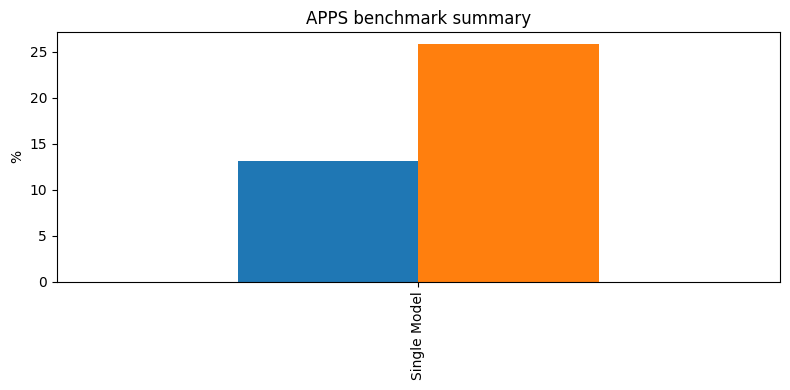

Saved evaluated results to: /content/drive/MyDrive/huggingface models/Qwen2.5-Coder-3B-Instruct/evaluated_results.csv


In [ ]:
# Summary statistics and plot.

import matplotlib.pyplot as plt
from IPython.display import display

def summarize_results(df: pd.DataFrame):
    if df.empty:
        print("No results.")
        return

    df_safe = df.copy()
    df_safe["public_test_pass_pct"] = df_safe["pass_rate"] * 100.0

    summary = pd.DataFrame(
        {
            "Single Model": [
                df_safe["solved"].mean() * 100.0,
                df_safe["public_test_pass_pct"].mean(),
                df_safe["generation_time_s"].mean(),
            ]
        },
        index=["problem_solved_%", "public_test_pass_%", "avg_generation_time_s"],
    )

    print("Overall summary")
    display(summary)

    if "difficulty" in df_safe.columns:
        by_diff = (
            df_safe.groupby("difficulty")
            .agg(
                problem_solved_pct=("solved", lambda s: s.mean() * 100.0),
                public_test_pass_pct=("public_test_pass_pct", "mean"),
                avg_generation_time_s=("generation_time_s", "mean"),
                n=("problem_id", "count"),
            )
            .reset_index()
        )

        print("By difficulty")
        display(by_diff)

    ax = summary.loc[["problem_solved_%", "public_test_pass_%"]].T.plot(
        kind="bar",
        figsize=(8, 4),
        legend=False,
    )
    ax.set_ylabel("%")
    ax.set_xlabel("")
    ax.set_title("APPS benchmark summary")
    plt.tight_layout()
    plt.show()

summarize_results(df_results)

EVAL_SAVE_PATH = os.path.join(ARTIFACT_DIR, "evaluated_results.csv")
df_results.to_csv(EVAL_SAVE_PATH, index=False)
print(f"Saved evaluated results to: {EVAL_SAVE_PATH}")


# LiveCodeBench Evaluation Pipelines

# LCB Single model pipeline

### Scenario 1 & 2: Single Model Evaluation

This section handles the evaluation of single-model pass-throughs for LiveCodeBench.

*   **Scenario 1:** Evaluates `Qwen/Qwen2.5-Coder-14B-Instruct-AWQ` (Quantized 14B model).
*   **Scenario 2:** Evaluates `Qwen/Qwen2.5-Coder-3B-Instruct` (Baseline 3B model).

**Note:** You can switch between these two scenarios by updating the `MODEL_NAME` variable in the configuration cell below immediately following the setup.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Load LiveCodeBench and install dependencies
# !pip install "datasets<3"
!git clone https://github.com/LiveCodeBench/LiveCodeBench.git
%cd LiveCodeBench
!pip install -e .

In [ ]:
from datetime import datetime

# --- Config: Single-Model Pipeline ---
MODEL_NAME = "Qwen/Qwen2.5-Coder-14B-Instruct-AWQ"
MODEL_SHORT_NAME = "Qwen2.5-Coder-14B-Ins"
MAX_MODEL_LEN = 4096
GPU_MEMORY_UTILIZATION = 0.85

# File Paths
PROBLEMS_FILEPATH = "/content/drive/MyDrive/problems_hard.pkl"

# Date Filtering & Versioning
MODEL_RELEASE_DATE = "2025-01-22"
END_DATE = "2025-04-07"
RELEASE_VERSION = "release_v6"

# Formatting date for LCB entry
_date = datetime.strptime(MODEL_RELEASE_DATE, "%Y-%m-%d")
MODEL_RELEASE_DATE_FMT = f"datetime({_date.year}, {_date.month}, {_date.day})"

### Patches to LCB

In [ ]:
# Add model description to livecodebench if it doesn't already exist.
import textwrap
styles_path = "lcb_runner/lm_styles.py"

# Inject custom model entry. Edit above & current cell as required if it's not a CodeQwenInstruct.
# Ask claude how to if it's a different type of model from CodeQwenInstruct
entry = textwrap.dedent(f"""
    LanguageModel(
        "{MODEL_NAME}",
        "{MODEL_SHORT_NAME}",
        LMStyle.CodeQwenInstruct,
        {MODEL_RELEASE_DATE_FMT},
        link="https://huggingface.co/{MODEL_NAME}"
    ),
""")

with open(styles_path, "r") as f:
    content = f.read()

if MODEL_NAME not in content:
    content = content.replace(
        "LanguageModelList: list[LanguageModel] = [",
        "LanguageModelList: list[LanguageModel] = [\n" + entry
    )
    with open(styles_path, "w") as f:
        f.write(content)
    print("✅ Model entry added")
else:
    print("ℹ️ Model entry already exists")

In [ ]:
# Patch load_code_generation_dataset to use streaming + early date filtering
# to avoid loading all problems into memory at once (crashes on Colab free tier)
codegen_path = "lcb_runner/benchmarks/code_generation.py"

original_func = '''def load_code_generation_dataset(release_version="release_v1", start_date=None, end_date=None) -> list[CodeGenerationProblem]:
    dataset = load_dataset("livecodebench/code_generation_lite", split="test", version_tag=release_version, trust_remote_code=True)
    dataset = [CodeGenerationProblem(**p) for p in dataset]  # type: ignore
    if start_date is not None:
        p_start_date = datetime.strptime(start_date, "%Y-%m-%d")
        dataset = [e for e in dataset if p_start_date <= e.contest_date]

    if end_date is not None:
        p_end_date = datetime.strptime(end_date, "%Y-%m-%d")
        dataset = [e for e in dataset if e.contest_date <= p_end_date]

    print(f"Loaded {len(dataset)} problems")
    return dataset'''

patched_func = '''def load_code_generation_dataset(release_version="release_v1", start_date=None, end_date=None, filepath=None) -> list[CodeGenerationProblem]:
    # Modified: supports loading from a pickle file or streaming from HuggingFace
    if filepath is not None:
        import pickle
        with open(filepath, "rb") as f:
            dataset = pickle.load(f)
    else:
        from tqdm import tqdm
        dataset = load_dataset("livecodebench/code_generation_lite", split="test", version_tag=release_version, trust_remote_code=True, streaming=True)

        def date_filter(row):
            d = row["contest_date"][:10]
            if start_date is not None and d < start_date:
                return False
            if end_date is not None and d > end_date:
                return False
            return True

        filtered = [row for row in tqdm(dataset) if date_filter(row)]
        dataset = [CodeGenerationProblem(**p) for p in filtered]
        print(f"Loaded {len(dataset)} problems")
        return dataset

    if start_date is not None:
        p_start_date = datetime.strptime(start_date, "%Y-%m-%d")
        dataset = [e for e in dataset if p_start_date <= e.contest_date]
    if end_date is not None:
        p_end_date = datetime.strptime(end_date, "%Y-%m-%d")
        dataset = [e for e in dataset if e.contest_date <= p_end_date]

    print(f"Loaded {len(dataset)} problems")
    return dataset'''

with open(codegen_path, "r") as f:
    content = f.read()

if "# Modified: supports loading from a pickle file" not in content:
    new_content = content.replace(original_func, patched_func)
    if new_content == content:
        print("⚠️ Could not find original function to patch — check if code_generation.py has changed")
    else:
        with open(codegen_path, "w") as f:
            f.write(new_content)
        print("✅ code_generation.py patched with pickle/streaming loader")
else:
    print("ℹ️ code_generation.py already patched")

In [ ]:
vllm_runner_path = "lcb_runner/runner/vllm_runner.py"

with open(vllm_runner_path, "r") as f:
    content = f.read()

new_content = content

if "max_model_len" not in content:
    new_content = new_content.replace(
        "trust_remote_code=args.trust_remote_code,",
        f"trust_remote_code=args.trust_remote_code,\n            max_model_len={MAX_MODEL_LEN},"
    )
    print(f"✅ Patched max_model_len={MAX_MODEL_LEN}")
else:
    print("ℹ️ max_model_len already patched")

if "gpu_memory_utilization" not in new_content:
    new_content = new_content.replace(
        "trust_remote_code=args.trust_remote_code,",
        f"trust_remote_code=args.trust_remote_code,\n            gpu_memory_utilization={GPU_MEMORY_UTILIZATION},"
    )
    print(f"✅ Patched gpu_memory_utilization={GPU_MEMORY_UTILIZATION}")
else:
    print("ℹ️ gpu_memory_utilization already patched")

with open(vllm_runner_path, "w") as f:
    f.write(new_content)

In [ ]:
parser_path = "lcb_runner/runner/parser.py"

original_arg = '''    parser.add_argument(
        "--end_date",
        type=str,
        default=None,
        help="End date for the contest to filter the evaluation file (format - YYYY-MM-DD)",
    )'''

patched_arg = '''    parser.add_argument(
        "--end_date",
        type=str,
        default=None,
        help="End date for the contest to filter the evaluation file (format - YYYY-MM-DD)",
    )
    parser.add_argument(
        "--filepath",
        type=str,
        default=None,
        help="Path to a pickle file to load problems from instead of HuggingFace",
    )'''

with open(parser_path, "r") as f:
    content = f.read()

if '"--filepath"' not in content:
    new_content = content.replace(original_arg, patched_arg)
    if new_content == content:
        print("⚠️ Could not find --end_date block to patch — check parser.py")
    else:
        with open(parser_path, "w") as f:
            f.write(new_content)
        print("✅ parser.py patched with --filepath argument")
else:
    print("ℹ️ parser.py already patched")

In [ ]:
router_path = "lcb_runner/runner/scenario_router.py"

original_call = '''            benchmark = load_code_generation_dataset(
                args.release_version,
                start_date=args.start_date,
                end_date=args.end_date
            )'''

patched_call = '''            benchmark = load_code_generation_dataset(
                args.release_version,
                start_date=args.start_date,
                end_date=args.end_date,
                filepath=args.filepath
            )'''

with open(router_path, "r") as f:
    content = f.read()

if "filepath=args.filepath" not in content:
    new_content = content.replace(original_call, patched_call)
    if new_content == content:
        print("⚠️ Could not find call to patch — check scenario_router.py")
    else:
        with open(router_path, "w") as f:
            f.write(new_content)
        print("✅ scenario_router.py patched with filepath argument")
else:
    print("ℹ️ scenario_router.py already patched")

### Generate code

In [ ]:
!python -m lcb_runner.runner.main \
    --model {MODEL_NAME} \
    --scenario codegeneration \
    --filepath {PROBLEMS_FILEPATH} \
    --dtype half \
    --n 1

### Evaluate Code

In [ ]:
# Evaluate generated prompts.
!python -m lcb_runner.runner.main \
    --model {MODEL_NAME} \
    --scenario codegeneration \
    --filepath {PROBLEMS_FILEPATH} \
    --dtype half \
    --n 1 \
    --num_process_evaluate 1 \
    --continue_existing_with_eval \
    --evaluate

# LCB planner-coder pipeline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Load LiveCodeBench and install dependencies
# !pip install "datasets<3"
!git clone https://github.com/LiveCodeBench/LiveCodeBench.git
%cd LiveCodeBench
!pip install -e .

### LCB Scenarios 3 & 4: Planner-Coder Pipelines

This section covers the evaluation of multi-stage reasoning and coding workflows using LiveCodeBench. You can toggle between the following two scenarios by modifying the `MODEL_NAME` and `MODEL_STYLE` variables in the configuration cell below:

*   **Scenario 3: DeepSeek Thinker + Qwen Coder**
    *   **Reasoner Model:** `deepseek-ai/DeepSeek-R1-Distill-Qwen-7B`
    *   **Coder Model:** `Qwen/Qwen2.5-Coder-3B-Instruct`
    *   *Configuration:* Set `MODEL_NAME` to the DeepSeek model and `MODEL_STYLE` to `LMStyle.DeepSeekR1` to leverage distilled reasoning for plan generation.

*   **Scenario 4: Qwen Planner + Qwen Coder**
    *   **Planner Model:** `Qwen/Qwen2.5-Coder-3B-Instruct`
    *   **Coder Model:** `Qwen/Qwen2.5-Coder-3B-Instruct`
    *   *Configuration:* Set `MODEL_NAME` to the Qwen model and `MODEL_STYLE` to `LMStyle.CodeQwenInstruct` for a unified planning and coding approach using the 3B Coder model.

In [ ]:
from datetime import datetime

# --- Config: Two-Model Pipeline ---

# 1. Thinking / Reasoner Model
# MODEL_NAME = "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B"
# MODEL_SHORT_NAME = "DeepSeek-R1-Distill-Qwen-7B"
# MAX_MODEL_LEN = 4096
# MODEL_STYLE = "LMStyle.DeepSeekR1"

# 2. Coder Model
MODEL_NAME = "Qwen/Qwen2.5-Coder-3B-Instruct"
MODEL_SHORT_NAME = "Qwen2.5-Coder-3B-Ins"
MAX_MODEL_LEN = 8192
MODEL_STYLE = "LMStyle.CodeQwenInstruct"

# File Paths
PROBLEMS_FILEPATH = "/content/drive/MyDrive/problems_hard.pkl"
# GPU
GPU_MEMORY_UTILIZATION = 0.85

# Date Filtering & Versioning
MODEL_RELEASE_DATE = "2025-01-22"
END_DATE = "2025-04-07"
RELEASE_VERSION = "release_v6"

# Formatting date for LCB entry
_date = datetime.strptime(MODEL_RELEASE_DATE, "%Y-%m-%d")
MODEL_RELEASE_DATE_FMT = f"datetime({_date.year}, {_date.month}, {_date.day})"

### Patches to LCB

In [ ]:
# Add model description to livecodebench if it doesn't already exist.
import textwrap
styles_path = "lcb_runner/lm_styles.py"

# Inject custom model entry. Edit above & current cell as required if it's not a CodeQwenInstruct.
# Ask claude how to if it's a different type of model from CodeQwenInstruct
entry = textwrap.dedent(f"""
    LanguageModel(
        "{MODEL_NAME}",
        "{MODEL_SHORT_NAME}",
        {MODEL_STYLE},
        {MODEL_RELEASE_DATE_FMT},
        link="https://huggingface.co/{MODEL_NAME}"
    ),
""")

with open(styles_path, "r") as f:
    content = f.read()

if MODEL_NAME not in content:
    content = content.replace(
        "LanguageModelList: list[LanguageModel] = [",
        "LanguageModelList: list[LanguageModel] = [\n" + entry
    )
    with open(styles_path, "w") as f:
        f.write(content)
    print("✅ Model entry added")
else:
    print("ℹ️ Model entry already exists")

✅ Model entry added


In [ ]:
# Patch load_code_generation_dataset to use streaming + early date filtering
# to avoid loading all problems into memory at once (crashes on Colab free tier)
codegen_path = "lcb_runner/benchmarks/code_generation.py"

original_func = '''def load_code_generation_dataset(release_version="release_v1", start_date=None, end_date=None) -> list[CodeGenerationProblem]:
    dataset = load_dataset("livecodebench/code_generation_lite", split="test", version_tag=release_version, trust_remote_code=True)
    dataset = [CodeGenerationProblem(**p) for p in dataset]  # type: ignore
    if start_date is not None:
        p_start_date = datetime.strptime(start_date, "%Y-%m-%d")
        dataset = [e for e in dataset if p_start_date <= e.contest_date]

    if end_date is not None:
        p_end_date = datetime.strptime(end_date, "%Y-%m-%d")
        dataset = [e for e in dataset if e.contest_date <= p_end_date]

    print(f"Loaded {len(dataset)} problems")
    return dataset'''

patched_func = '''def load_code_generation_dataset(release_version="release_v1", start_date=None, end_date=None, filepath=None) -> list[CodeGenerationProblem]:
    # Modified: supports loading from a pickle file or streaming from HuggingFace
    if filepath is not None:
        import pickle
        with open(filepath, "rb") as f:
            dataset = pickle.load(f)
    else:
        from tqdm import tqdm
        dataset = load_dataset("livecodebench/code_generation_lite", split="test", version_tag=release_version, trust_remote_code=True, streaming=True)

        def date_filter(row):
            d = row["contest_date"][:10]
            if start_date is not None and d < start_date:
                return False
            if end_date is not None and d > end_date:
                return False
            return True

        filtered = [row for row in tqdm(dataset) if date_filter(row)]
        dataset = [CodeGenerationProblem(**p) for p in filtered]
        print(f"Loaded {len(dataset)} problems")
        return dataset

    if start_date is not None:
        p_start_date = datetime.strptime(start_date, "%Y-%m-%d")
        dataset = [e for e in dataset if p_start_date <= e.contest_date]
    if end_date is not None:
        p_end_date = datetime.strptime(end_date, "%Y-%m-%d")
        dataset = [e for e in dataset if e.contest_date <= p_end_date]

    print(f"Loaded {len(dataset)} problems")
    return dataset'''

with open(codegen_path, "r") as f:
    content = f.read()

if "# Modified: supports loading from a pickle file" not in content:
    new_content = content.replace(original_func, patched_func)
    if new_content == content:
        print("⚠️ Could not find original function to patch — check if code_generation.py has changed")
    else:
        with open(codegen_path, "w") as f:
            f.write(new_content)
        print("✅ code_generation.py patched with pickle/streaming loader")
else:
    print("ℹ️ code_generation.py already patched")

✅ code_generation.py patched with pickle/streaming loader


In [ ]:
vllm_runner_path = "lcb_runner/runner/vllm_runner.py"

with open(vllm_runner_path, "r") as f:
    content = f.read()

new_content = content

if "max_model_len" not in content:
    new_content = new_content.replace(
        "trust_remote_code=args.trust_remote_code,",
        f"trust_remote_code=args.trust_remote_code,\n            max_model_len={MAX_MODEL_LEN},"
    )
    print(f"✅ Patched max_model_len={MAX_MODEL_LEN}")
else:
    print("ℹ️ max_model_len already patched")

if "gpu_memory_utilization" not in new_content:
    new_content = new_content.replace(
        "trust_remote_code=args.trust_remote_code,",
        f"trust_remote_code=args.trust_remote_code,\n            gpu_memory_utilization={GPU_MEMORY_UTILIZATION},"
    )
    print(f"✅ Patched gpu_memory_utilization={GPU_MEMORY_UTILIZATION}")
else:
    print("ℹ️ gpu_memory_utilization already patched")

with open(vllm_runner_path, "w") as f:
    f.write(new_content)

✅ Patched max_model_len=8192
✅ Patched gpu_memory_utilization=0.85


In [ ]:
parser_path = "lcb_runner/runner/parser.py"

original_arg = '''    parser.add_argument(
        "--end_date",
        type=str,
        default=None,
        help="End date for the contest to filter the evaluation file (format - YYYY-MM-DD)",
    )'''

patched_arg = '''    parser.add_argument(
        "--end_date",
        type=str,
        default=None,
        help="End date for the contest to filter the evaluation file (format - YYYY-MM-DD)",
    )
    parser.add_argument(
        "--filepath",
        type=str,
        default=None,
        help="Path to a pickle file to load problems from instead of HuggingFace",
    )'''

with open(parser_path, "r") as f:
    content = f.read()

if '"--filepath"' not in content:
    new_content = content.replace(original_arg, patched_arg)
    if new_content == content:
        print("⚠️ Could not find --end_date block to patch — check parser.py")
    else:
        with open(parser_path, "w") as f:
            f.write(new_content)
        print("✅ parser.py patched with --filepath argument")
else:
    print("ℹ️ parser.py already patched")

✅ parser.py patched with --filepath argument


In [ ]:
router_path = "lcb_runner/runner/scenario_router.py"

original_call = '''            benchmark = load_code_generation_dataset(
                args.release_version,
                start_date=args.start_date,
                end_date=args.end_date
            )'''

patched_call = '''            benchmark = load_code_generation_dataset(
                args.release_version,
                start_date=args.start_date,
                end_date=args.end_date,
                filepath=args.filepath
            )'''

with open(router_path, "r") as f:
    content = f.read()

if "filepath=args.filepath" not in content:
    new_content = content.replace(original_call, patched_call)
    if new_content == content:
        print("⚠️ Could not find call to patch — check scenario_router.py")
    else:
        with open(router_path, "w") as f:
            f.write(new_content)
        print("✅ scenario_router.py patched with filepath argument")
else:
    print("ℹ️ scenario_router.py already patched")

✅ scenario_router.py patched with filepath argument


### Generate code

### Planner-Coder Execution Guide: Two-Pass Workflow

This pipeline requires a manual two-pass process to bridge the gap between algorithmic reasoning and final implementation. Follow these steps to execute the workflow:

#### Pass 1: Plan Generation
1. **Define Planning Logic**: In the cells below, ensure the `format_prompt_generation` function is defined using the **'Planning'** logic. This logic prompts the model (e.g., DeepSeek-R1 or Qwen) to generate a step-by-step algorithmic plan without writing code.
2. **Run Execution**: Run the main execution script (`lcb_runner.runner.main`). The model will generate plans for the problems defined in your filtered dataset.

#### Pass 2: Code Generation
1. **Save and Load Plans**: Once the planning pass is complete, extract the generated plans from the results JSON and save them to `/content/drive/MyDrive/plans.json` (as shown in the 'Save plans' section).
2. **Define Coding Logic**: Redefine the `format_prompt_generation` function using the **'Coding'** logic. This version of the function specifically loads the generated plan from `plans.json` and injects it into the prompt for the Coder model.
3. **Run Implementation & Evaluation**: Run the execution script again, this time including the `--evaluate` flag. The Coder model will use the previously generated plans to synthesize and test the final Python solutions.

**Note**: This two-pass manual approach is necessary to ensure the Coder model is strictly informed by the Reasoning model's logical output, simulating a multi-agent reasoning chain.

In [ ]:
from lcb_runner.benchmarks.code_generation import CodeGenerationProblem
from lcb_runner.lm_styles import LMStyle
from lcb_runner.prompts.code_generation import PromptConstants
import lcb_runner.runner.scenario_router as sr
import json

logged_prompts = []

with open("/content/drive/MyDrive/plans.json") as f:
    plans_data = json.load(f)

plans_by_id = {p["question_id"]: p["generated_plan"] for p in plans_data}

def get_codeqwen_question_template_answer(question: CodeGenerationProblem):
    prompt = "You will be given a question (problem specification) and will generate a correct Python program that matches the specification and passes all tests. You will NOT return anything except for the program.\n\n"
    prompt += f"Question: {question.question_content}\n\n"
    plan = plans_by_id.get(question.question_id)
    if plan:
        prompt += f"Here is a plan to solve the problem:\n{plan}\n\n"
    if question.starter_code:
        prompt += f"{PromptConstants.FORMATTING_MESSAGE_WITH_STARTER_CODE}\n"
        prompt += f"```python\n{question.starter_code}\n```\n\n<|im_end|>\n"
    else:
        prompt += f"{PromptConstants.FORMATTING_WITHOUT_STARTER_CODE}\n"
        prompt += f"```python\n# YOUR CODE HERE\n```\n\n<|im_end|>\n"
    prompt += f"<|im_start|>assistant\n"
    return prompt

def get_codeqwen_plan_template(question: CodeGenerationProblem):
    prompt = "You will be given a question (problem specification). Generate a step-by-step plan to solve it. Do NOT write code.\n\n"
    prompt += f"Question: {question.question_content}\n\n"
    prompt += f"<|im_end|>\n"
    prompt += f"<|im_start|>assistant\n"
    return prompt

In [ ]:
SYSTEM_MESSAGE_DEEPSEEK_R1 = (
        "<｜begin▁of▁sentence｜>A conversation between User and Assistant. "
        "The user asks a question, and the Assistant solves it. "
        "The assistant first thinks about the reasoning process in the mind and then provides the user with the answer. "
        "The reasoning process and answer are enclosed within <think> </think> and <answer> </answer> tags, respectively, i.e., <think> reasoning process here </think> <answer> answer here </answer>.<｜User｜>"
    )

def get_deepseek_r1_question_template_answer(question: CodeGenerationProblem):
    # Following modifications from: https://github.com/fanqiwan/FuseAI/blob/main/FuseO1-Preview/code_evaluation/lcb_runner_cq/prompts/code_generation.py
    prompt = "You will be given a question (problem specification). Generate a step-by-step plan to solve it. Do NOT write code.\n\n"
    prompt += f"Question: {question.question_content}\n\n"
    return prompt

In [ ]:
# Planning

def format_prompt_generation(question, LanguageModelStyle):
    if LanguageModelStyle == LMStyle.CodeQwenInstruct:
        prompt = f"{PromptConstants.SYSTEM_MESSAGE_CODEQWEN}\n\n"
        prompt += get_codeqwen_plan_template(question)
    if LanguageModelStyle == LMStyle.DeepSeekR1:
        prompt = f"{PromptConstants.SYSTEM_MESSAGE_DEEPSEEK_R1}"
        prompt += f"{get_deepseek_r1_question_template_answer(question)}"
        return prompt

In [ ]:
# Coding
def format_prompt_generation(question, LanguageModelStyle):
    if LanguageModelStyle == LMStyle.CodeQwenInstruct:
        prompt = f"{PromptConstants.SYSTEM_MESSAGE_CODEQWEN}\n\n"
        prompt += f"{get_codeqwen_question_template_answer(question)}"
        logged_prompts.append({"question_id": question.question_id, "prompt": prompt})
        return prompt

In [ ]:
sr.format_prompt_generation = format_prompt_generation

In [ ]:
import sys

sys.argv = [
    "main.py",
    "--model", MODEL_NAME,
    "--scenario", "codegeneration",
    "--filepath", PROBLEMS_FILEPATH,
    "--dtype", "half",
    "--n", "1"
]

from lcb_runner.runner.main import main
main()

Loaded 33 problems
INFO 04-11 15:17:38 [utils.py:233] non-default args: {'tokenizer': 'Qwen/Qwen2.5-Coder-3B-Instruct', 'dtype': 'half', 'max_model_len': 8192, 'enable_prefix_caching': False, 'gpu_memory_utilization': 0.85, 'disable_log_stats': True, 'enforce_eager': True, 'disable_custom_all_reduce': True, 'model': 'Qwen/Qwen2.5-Coder-3B-Instruct'}


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

INFO 04-11 15:18:03 [model.py:549] Resolved architecture: Qwen2ForCausalLM
WARNING 04-11 15:18:03 [model.py:2016] Casting torch.bfloat16 to torch.float16.
INFO 04-11 15:18:03 [model.py:1678] Using max model len 8192
INFO 04-11 15:18:03 [scheduler.py:238] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 04-11 15:18:03 [vllm.py:790] Asynchronous scheduling is enabled.
WARNING 04-11 15:18:03 [vllm.py:848] Enforce eager set, disabling torch.compile and CUDAGraphs. This is equivalent to setting -cc.mode=none -cc.cudagraph_mode=none
WARNING 04-11 15:18:03 [vllm.py:859] Inductor compilation was disabled by user settings, optimizations settings that are only active during inductor compilation will be ignored.
INFO 04-11 15:18:03 [vllm.py:1025] Cudagraph is disabled under eager mode
INFO 04-11 15:18:03 [compilation.py:290] Enabled custom fusions: norm_quant, act_quant


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

WARNING 04-11 15:18:05 [system_utils.py:152] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing for more information. Reasons: CUDA is initialized


Rendering prompts:   0%|          | 0/33 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/33 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

### Save plans

In [ ]:
import json

output_path = f"output/{MODEL_SHORT_NAME}/Scenario.codegeneration_1_0.2.json"
with open(output_path) as f:
    save_results = json.load(f)

In [ ]:
combined = []
for result in save_results:
    combined.append({
        "question_id": result["question_id"],
        "generated_plan": result["output_list"][0] if result["output_list"] else None
    })

with open("/content/drive/MyDrive/plans.json", "w") as f:
    json.dump(combined, f, indent=2)

print(f"✅ Saved {len(combined)} plans to plans.json")

✅ Saved 33 plans to plans.json


### Evaluate Code

In [ ]:
# Evaluate generated prompts. Run in second run.
# %cd LiveCodeBench
!python -m lcb_runner.runner.main \
    --model {MODEL_NAME} \
    --scenario codegeneration \
    --filepath {PROBLEMS_FILEPATH} \
    --dtype half \
    --n 1 \
    --num_process_evaluate 1 \
    --continue_existing_with_eval \
    --evaluate

Loaded 33 problems
Found 33 existing generations, continuing with 0 remaining
Evaluating 33...
 27% 9/33 [00:14<00:44,  1.84s/it]3
4
6
1
6
100% 33/33 [00:29<00:00,  1.14it/s]
0.030303030303030304
